In [1]:
import sys, os
sys.path.append(os.path.join('/home/module'))
import pgd_imp_old as imp
import pandas as pd

import math
import pandas as pd
from google.cloud import bigquery
from google.oauth2 import service_account

/opt/conda/lib/python3.8/site-packages/google/cloud/bigquery_storage_v1/__init__.py:57: FutureWarning: You are using a non-supported Python version (3.8.16).  Google will not post any further updates to google.cloud.bigquery_storage_v1 supporting this Python version. Please upgrade to the latest Python version, or at least to Python 3.9, and then update google.cloud.bigquery_storage_v1.
  warnings.warn(


In [2]:
import math
import pandas as pd
from datetime import datetime, timedelta
from google.cloud import bigquery
from google.oauth2 import service_account

import sys, os
sys.path.append(os.path.join('/home/module'))
from Bq_Connect import BQDataProcessor 

# setup BigQuery client sekali
key_path = '/home/jupyterhub/SA/jupyter-pgd-prod-data-analytics-0fa0e01ee70a.json'
credentials = service_account.Credentials.from_service_account_file(
    key_path, scopes=["https://www.googleapis.com/auth/cloud-platform"],
)
bq_client = bigquery.Client(credentials=credentials, project=credentials.project_id)
run = BQDataProcessor(env="prod") 

[BQDataProcessor] Connected → env=PROD, project=pgd-prod-data-analytics, SA=default (/home/jupyterhub/SA/jupyter-pgd-prod-data-analytics-0fa0e01ee70a.json)


In [3]:
run = imp.DataProcessor()

In [4]:
dtype_to_bq = {
    'object': 'STRING',
    'int64': 'INT64',
    'int32': 'INT64',
    'float64': 'FLOAT64',
    'datetime64[ns]': 'TIMESTAMP',
}

In [5]:
from datetime import datetime, timedelta, date
from dateutil.relativedelta import relativedelta

today = datetime.today() - relativedelta(days=1)
yesterday = today - relativedelta(days=1)
last_week = today - relativedelta(days=7)
last_2week = last_week - relativedelta(days=7)
last_month = today  - relativedelta(months=1)
last_2month = last_month - relativedelta(months=1)
last_year = today - relativedelta(years=1)

first_this_year = today + relativedelta(month=1, day=1)
first_last_year = today - relativedelta(years=1, month=1, day=1)

today=today.strftime('%Y-%m-%d')
yesterday=yesterday.strftime('%Y-%m-%d')
last_week=last_week.strftime('%Y-%m-%d')
last_2week=last_2week.strftime('%Y-%m-%d')
last_month=last_month.strftime('%Y-%m-%d')
last_2month=last_2month.strftime('%Y-%m-%d')
last_year=last_year.strftime('%Y-%m-%d')
first_this_year=first_this_year.strftime('%Y-%m-%d')
first_last_year=first_last_year.strftime('%Y-%m-%d')


today = date.fromisoformat(today)
last_year = date.fromisoformat(last_year)

print('today: ', today)
print('yesterday: ', yesterday)
print('last_week: ', last_week)
print('last_2week: ', last_2week)
print('last_month: ', last_month)
print('last_2month: ', last_2month)
print('last_year: ', last_year)
print('first_this_year: ', first_this_year)
print('first_last_year: ', first_last_year)




today:  2026-04-16
yesterday:  2026-04-15
last_week:  2026-04-09
last_2week:  2026-04-02
last_month:  2026-03-16
last_2month:  2026-02-16
last_year:  2025-04-16
first_this_year:  2026-01-01
first_last_year:  2025-01-01


In [6]:
run.execute_ddl("invalidate metadata datalake.pgd_tbl_transaksi_nontunai") # kalo ada permasalah di impala

False

Load &Prepare Data

In [7]:
# today=  '2026-02-11'
# yesterday=  '2026-02-10'
# last_week=  '2026-02-04'
# last_2week=  '2026-01-28'
# last_month=  '2026-01-11'
# last_2month=  '2025-12-11'
# last_year=  '2025-02-11'
# first_this_year=  '2026-01-01'
# first_last_year=  '2025-01-01'

# today=  '2026-02-19'
# yesterday=  '2026-02-18'
# last_week=  '2026-02-12'
# last_2week=  '2026-02-05'
# last_month=  '2026-01-19'
# last_2month=  '2025-12-19'
# last_year=  '2025-02-19'
# first_this_year=  '2026-01-01'
# first_last_year=  '2025-01-01'

In [53]:
# daily, weekly, monthly, yearly growht transacation 
# new box
sql = f"""

with tk AS (
  SELECT 
    kr.tgl_transaksi,
    kr.create_by,
    kr.branch_code,
    --kolom untuk mencari kenaikan up tertinggi per kontrak
    ((up - LAG(up) OVER (ORDER BY tgl_transaksi)) * 1.0 / NULLIF(LAG(up) OVER (ORDER BY tgl_transaksi), 0))/count(no_kontrak) AS growth_rate
  FROM datalake.pgd_tbl_transaksi_kredit kr
  left join datalake.pgd_tbl_transaction_handler h
        ON kr.kode_transaksi = h.kode_transaksi
  where
        h.description like '%CAIR%'
  group by kr.create_by, kr.branch_code, 
  kr.tgl_transaksi, kr.up
),
monthly_max AS (
  SELECT 
    MAX(growth_rate) as max_monthly_growth,
    create_by,
    branch_code
  FROM tk
  WHERE tgl_transaksi >= date_sub('{last_month}',1)
  group by create_by, branch_code
),
yearly_max AS (
  SELECT 
    MAX(growth_rate) as max_yearly_growth,
    create_by,
    branch_code
  FROM tk
  WHERE tgl_transaksi >= date_sub('{last_year}', 1)
  group by create_by, branch_code
), 
trx_hari_ini as
    (
    SELECT 
        tk.create_by,
        tk.branch_code,
        sum(tk.up)             total_pinjaman_hari_ini,
        count(tk.no_kontrak)   jumlah_kontrak_hari_ini
    FROM datalake.pgd_tbl_transaksi_kredit tk
        left join datalake.pgd_tbl_transaction_handler h 
                ON tk.kode_transaksi = h.kode_transaksi
    where 
        h.description like '%CAIR%' 
        and tk.tgl_transaksi <= date_sub('{today}',1)
        and tk.tgl_transaksi >= date_sub('{today}',1)
    group by tk.create_by, tk.branch_code
    ),
    
trx_kemarin as
    (
    SELECT 
        tk.create_by,
        tk.branch_code,
        sum(tk.up)             total_pinjaman_kemarin,
        count(tk.no_kontrak)   jumlah_kontrak_kemarin
    FROM datalake.pgd_tbl_transaksi_kredit tk
        left join datalake.pgd_tbl_transaction_handler h 
                ON tk.kode_transaksi = h.kode_transaksi
    where 
        h.description like '%CAIR%' 
        and tk.tgl_transaksi <= date_sub('{yesterday}',1)
        and tk.tgl_transaksi >= date_sub('{yesterday}',1)
    group by tk.create_by, tk.branch_code
    ),

trx_minggu_ini as
    (
    SELECT 
        tk.create_by,
        tk.branch_code,
        sum(tk.up) / count(distinct tk.tgl_transaksi)             as total_pinjaman_minggu_ini,     -- jadinya rata-rata per hari
        count(tk.no_kontrak) / count(distinct tk.tgl_transaksi)   as jumlah_kontrak_minggu_ini      -- jadinya rata-rata per hari
    FROM datalake.pgd_tbl_transaksi_kredit tk
        left join datalake.pgd_tbl_transaction_handler h 
                ON tk.kode_transaksi = h.kode_transaksi
    where 
        h.description like '%CAIR%' 
        and tk.tgl_transaksi <= date_sub('{today}',1)
        and tk.tgl_transaksi >= date_sub('{last_week}',1)
    group by tk.create_by, tk.branch_code
    ),
    
trx_minggu_lalu as
    (
    SELECT 
        tk.create_by,
        tk.branch_code,
        sum(tk.up) / count(distinct tk.tgl_transaksi)             total_pinjaman_minggu_lalu,     -- jadinya rata-rata per hari
        count(tk.no_kontrak) / count(distinct tk.tgl_transaksi)   jumlah_kontrak_minggu_lalu      -- jadinya rata-rata per hari
    FROM datalake.pgd_tbl_transaksi_kredit tk
        left join datalake.pgd_tbl_transaction_handler h 
                ON tk.kode_transaksi = h.kode_transaksi
    where 
        h.description like '%CAIR%' 
        and tk.tgl_transaksi <= date_sub('{last_week}',1)
        and tk.tgl_transaksi >= date_sub('{last_2week}',1)
    group by tk.create_by, tk.branch_code
    ),
    
trx_bulan_ini as
    (
    SELECT 
        tk.create_by,
        tk.branch_code,
        sum(tk.up) / count(distinct tk.tgl_transaksi)             total_pinjaman_bulan_ini,     -- jadinya rata-rata per hari
        count(tk.no_kontrak) / count(distinct tk.tgl_transaksi)   jumlah_kontrak_bulan_ini      -- jadinya rata-rata per hari
    FROM datalake.pgd_tbl_transaksi_kredit tk
        left join datalake.pgd_tbl_transaction_handler h 
                ON tk.kode_transaksi = h.kode_transaksi
    where 
        h.description like '%CAIR%' 
        and tk.tgl_transaksi <= date_sub('{today}',1)
        and tk.tgl_transaksi >= date_sub('{last_month}',1)
    group by tk.create_by, tk.branch_code
    ),
    
trx_bulan_lalu as
    (
    SELECT 
        tk.create_by,
        tk.branch_code,
        sum(tk.up) / count(distinct tk.tgl_transaksi)             total_pinjaman_bulan_lalu,     -- jadinya rata-rata per hari
        count(tk.no_kontrak) / count(distinct tk.tgl_transaksi)   jumlah_kontrak_bulan_lalu      -- jadinya rata-rata per hari
    FROM datalake.pgd_tbl_transaksi_kredit tk
        left join datalake.pgd_tbl_transaction_handler h 
                ON tk.kode_transaksi = h.kode_transaksi
    where 
        h.description like '%CAIR%' 
        and tk.tgl_transaksi <= date_sub('{last_month}',1)
        and tk.tgl_transaksi >= date_sub('{last_2month}',1)
    group by tk.create_by, tk.branch_code
    ),
    
trx_ytd_tahun_ini as
    (
    SELECT 
        tk.create_by,
        tk.branch_code,
        sum(tk.up) / count(distinct tk.tgl_transaksi)             total_pinjaman_tahun_ini,     -- jadinya rata-rata per hari
        count(tk.no_kontrak) / count(distinct tk.tgl_transaksi)   jumlah_kontrak_tahun_ini      -- jadinya rata-rata per hari
    FROM datalake.pgd_tbl_transaksi_kredit tk
        left join datalake.pgd_tbl_transaction_handler h 
                ON tk.kode_transaksi = h.kode_transaksi
    where 
        h.description like '%CAIR%' 
        and tk.tgl_transaksi <= date_sub('{today}',1)
        and tk.tgl_transaksi >= date_sub('{first_last_year}',0)
    group by tk.create_by, tk.branch_code
    ),
    
trx_ytd_tahun_lalu as
    (
    SELECT 
        tk.create_by,
        tk.branch_code,
        sum(tk.up) / count(distinct tk.tgl_transaksi)             total_pinjaman_tahun_lalu,     -- jadinya rata-rata per hari
        count(tk.no_kontrak) / count(distinct tk.tgl_transaksi)   jumlah_kontrak_tahun_lalu      -- jadinya rata-rata per hari
    FROM datalake.pgd_tbl_transaksi_kredit tk
        left join datalake.pgd_tbl_transaction_handler h 
                ON tk.kode_transaksi = h.kode_transaksi
    where 
        h.description like '%CAIR%' 
        and tk.tgl_transaksi <= date_sub('{last_year}',1)
        and tk.tgl_transaksi >= date_sub('{first_last_year}',0)
    group by tk.create_by, tk.branch_code
    ),
    
emp_cif as
    (
    -- CIF & NIK Karyawan Internal
    select 
        cus.cif, 
        emp.nik_pendek,
        emp.ktp,
        emp.branch_code
    from datalake.hcms_emp_cur_data emp
        inner join datalake.pgd_tbl_customer cus
        on emp.ktp = cus.no_id
    where emp.branch_code is not null 

    union all

    -- CIF dan NIK Karyawan Outsource
    select 
        cus.cif, 
        ara.employee_id as nik_pendek,
        ara.no_ktp as ktp,
        ara.kode_location as branch_code
    from raw.aralia_public_ms_employee ara -- ini kalau udah ada tabelnya yang bener mendingan diganti, jangan pake raw
        inner join datalake.pgd_tbl_customer cus
    on ara.no_ktp = cus.no_id
    where ara.importdate = 20260115 -- karena data yang paling update di tanggal ini & pake raw jadi musti masukin importdate
    ),
    
credit_as_customer as
    (
    select
        nik_pendek,
        sum(cr.up) acc_osl_as_cust
    from emp_cif ec
        left join datalake.pgd_tbl_kredit cr
        on ec.cif = cr.cif
    where
        cr.status_rek like '4'
        --cr.product_code in('01', '02') -- Produk Gadai
    group by ec.nik_pendek
    ),

rekbj_as_employee as
    (
    select distinct
        nik_pendek,
        x.jumlah_rek as jumlah_rek_as_emp,
        x.jumlah_bj as jumlah_bj_as_emp
    from emp_cif ec
    full outer join (
        select
            -- cr.cif,
            cr.create_by,
            count(distinct cr.no_kontrak) jumlah_rek,
            sum(bj.jumlah) jumlah_bj
        from datalake.pgd_tbl_kredit cr
        inner join DATALAKE.pgd_tbl_det_jam_kt bj
        on cr.account_no = bj.account_no
        WHERE
        cr.STATUS_REK='4'
        AND BJ.ACCOUNT_NO IS NOT NULL
        AND BJ.JUMLAH>0
        and cr.status_rek like '4'
        and cr.product_code in('01', '02') -- Produk Gadai
        --and cr.create_by like "P%"
        GROUP BY cr.create_by
        ) x
    on ec.nik_pendek = x.create_by
    where x.jumlah_rek is not null or x.jumlah_bj is not null),
    -- group by nik_pendek
    -- )

rekbj_as_customer as
    (
    select distinct
        nik_pendek,
        x.jumlah_rek as jumlah_rek_as_cust,
        x.jumlah_bj as jumlah_bj_as_cust
    from emp_cif ec
    full outer join (
    select
        cr.cif,
        -- cr.create_by,
        count(distinct cr.no_kontrak) jumlah_rek,
        sum(bj.jumlah) jumlah_bj
    from datalake.pgd_tbl_kredit cr
    inner join DATALAKE.pgd_tbl_det_jam_kt bj
    on cr.account_no = bj.account_no
    WHERE
    cr.STATUS_REK='4'
    AND BJ.ACCOUNT_NO IS NOT NULL
    AND BJ.JUMLAH>0
    and status_rek like '4'
    and product_code in('01', '02') -- Produk Gadai
    --and cr.create_by like "P%"
    GROUP BY cr.cif
    ) x
    on ec.cif = x.cif
    where x.jumlah_rek is not null or x.jumlah_bj is not null
    -- group by ec.nik_pendek
)

select distinct
    emp.nik_pendek,
    --hi.branch_code,
    --ke.branch_code,
    bi.branch_code,
    cac.acc_osl_as_cust,
    
    hi.total_pinjaman_hari_ini,
    hi.jumlah_kontrak_hari_ini,
    ke.total_pinjaman_kemarin,
    ke.jumlah_kontrak_kemarin,
    
    mi.total_pinjaman_minggu_ini,
    mi.jumlah_kontrak_minggu_ini,
    ml.total_pinjaman_minggu_lalu,
    ml.jumlah_kontrak_minggu_lalu,
    
    bi.total_pinjaman_bulan_ini,
    bi.jumlah_kontrak_bulan_ini,
    bl.total_pinjaman_bulan_lalu,
    bl.jumlah_kontrak_bulan_lalu,
    
    yi.total_pinjaman_tahun_ini,
    yi.jumlah_kontrak_tahun_ini,
    yl.total_pinjaman_tahun_lalu,
    yl.jumlah_kontrak_tahun_lalu,
    
    (hi.total_pinjaman_hari_ini / ke.total_pinjaman_kemarin) as rasio_daily_up_pencairan,
    (hi.jumlah_kontrak_hari_ini / ke.jumlah_kontrak_kemarin) as rasio_daily_ct_kontrak,
    
    (mi.total_pinjaman_minggu_ini / ml.total_pinjaman_minggu_lalu) as rasio_wtw_up_pencairan,
    (mi.jumlah_kontrak_minggu_ini / ml.jumlah_kontrak_minggu_lalu) as rasio_wtw_ct_kontrak,
    
    (bi.total_pinjaman_bulan_ini / bl.total_pinjaman_bulan_lalu) as rasio_mtm_up_pencairan,
    (bi.jumlah_kontrak_bulan_ini / bl.jumlah_kontrak_bulan_lalu) as rasio_mtm_ct_kontrak,
    
    (yi.total_pinjaman_tahun_ini / yl.total_pinjaman_tahun_lalu) as rasio_yoy_up_pencairan,
    (yi.jumlah_kontrak_tahun_ini / yl.jumlah_kontrak_tahun_lalu) as rasio_yoy_ct_kontrak,
    
    ym.max_yearly_growth,

    mm.max_monthly_growth,
    
    rac.jumlah_rek_as_cust,
    rac.jumlah_bj_as_cust,
    rae.jumlah_rek_as_emp,
    rae.jumlah_bj_as_emp,
    
    date_sub('{today}',1) as_dt
from 
    emp_cif emp
        
        full outer join rekbj_as_customer rac
            on emp.nik_pendek = rac.nik_pendek
        
        full outer join rekbj_as_employee rae
            on emp.nik_pendek = rae.nik_pendek

        full outer join yearly_max ym
            on emp.nik_pendek = ym.create_by
            --and ym.branch_code = yi.branch_code
        
        full outer join monthly_max mm
            on emp.nik_pendek = mm.create_by
            and ym.branch_code = mm.branch_code
        
        full outer join trx_ytd_tahun_lalu yl
            on emp.nik_pendek = yl.create_by
            and mm.branch_code = yl.branch_code
        
        full outer join trx_ytd_tahun_ini yi
            on emp.nik_pendek = yi.create_by
            and yl.branch_code = yi.branch_code
        
        full outer join trx_bulan_lalu bl
            on emp.nik_pendek = bl.create_by
            and yi.branch_code = bl.branch_code  
        
        full outer join trx_bulan_ini bi
            on emp.nik_pendek = bi.create_by
            and bl.branch_code = bi.branch_code
        
        full outer join trx_minggu_ini mi
            on emp.nik_pendek = mi.create_by
            and bi.branch_code = mi.branch_code
        
        full outer join trx_minggu_lalu ml
            on emp.nik_pendek = ml.create_by
            and mi.branch_code = ml.branch_code
        
        full outer join trx_kemarin ke
            on emp.nik_pendek = ke.create_by
            and ml.branch_code = ke.branch_code
        
        full outer join trx_hari_ini hi
            on emp.nik_pendek = hi.create_by
            and ke.branch_code = hi.branch_code
            
        full outer join credit_as_customer cac
            on emp.nik_pendek = cac.nik_pendek
            
           
            
        
            
where bi.branch_code is not null --and ml.branch_code is not null
order by nik_pendek, bi.branch_code asc
    
"""

emp_ml_v1 = run.read(sql)
emp_ml_v1.head(10)

,nik_pendek,branch_code,acc_osl_as_cust,total_pinjaman_bulan_ini,jumlah_kontrak_bulan_ini,total_pinjaman_bulan_lalu,jumlah_kontrak_bulan_lalu,total_pinjaman_tahun_ini,jumlah_kontrak_tahun_ini,total_pinjaman_tahun_lalu,...,rasio_mtm_ct_kontrak,rasio_yoy_up_pencairan,rasio_yoy_ct_kontrak,max_yearly_growth,max_monthly_growth,jumlah_rek_as_cust,jumlah_bj_as_cust,jumlah_rek_as_emp,jumlah_bj_as_emp,as_dt
0,P86617,60035,NaN,6.692760e+07,5.480000,3.994333e+07,4.944444,3.596997e+07,3.804124,2.876553e+07,...,1.108315,1.250454,0.892325,1665.666667,155.315789,NaN,None,NaN,None,2026-02-18
1,P86706,60723,100630000.0,2.070100e+08,19.000000,2.208685e+08,23.285714,1.450648e+08,17.382671,1.431087e+08,...,0.815951,1.013668,0.945157,381.978723,57.865248,1.0,1,137.0,244,2026-02-18
2,P86770,10925,221230000.0,2.492764e+08,14.320000,2.179995e+08,10.666667,1.597151e+08,15.760252,1.457832e+08,...,1.342500,1.095566,1.386318,1351.857143,265.333333,2.0,3,254.0,429,2026-02-18
3,P87084,11470,153276749.0,4.232150e+08,45.500000,2.569090e+08,29.142857,2.485272e+08,33.064286,2.748967e+08,...,1.561275,0.904075,0.813286,2149.666667,80.166667,6.0,8,1678.0,4534,2026-02-18
4,P87842,14305,59474500.0,2.931424e+08,16.680000,1.303590e+08,10.952381,1.480665e+08,17.382759,1.690326e+08,...,1.522957,0.875964,0.824944,1356.692308,167.750000,1.0,1,310.0,408,2026-02-18
5,P87904,14288,102932011.0,2.421800e+08,25.000000,1.542229e+08,18.857143,1.313280e+08,18.896429,1.277718e+08,...,1.325758,1.027832,0.964551,579.000000,20.612903,NaN,None,773.0,1122,2026-02-18
6,P88115,10701,239918100.0,3.158280e+08,21.600000,1.938875e+08,14.272727,1.441029e+08,12.021201,1.271597e+08,...,1.513376,1.133243,0.883570,393.177215,177.928571,3.0,7,62.0,112,2026-02-18
7,P88183,11080,469095000.0,1.438543e+08,14.320000,6.106200e+07,10.000000,8.687132e+07,12.103093,6.348789e+07,...,1.432000,1.368313,1.024315,328.670330,87.495575,9.0,12,608.0,839,2026-02-18
8,P88294,11534,405177000.0,1.720203e+08,20.520000,6.576600e+07,13.800000,1.486577e+08,22.133333,1.373507e+08,...,1.486957,1.082323,0.801932,130.200000,289.500000,NaN,None,647.0,826,2026-02-18
9,P88402,11469,13210000.0,1.394029e+08,27.357143,1.009471e+08,19.809524,9.623726e+07,22.442997,1.328616e+08,...,1.381010,0.724342,0.687215,729.500000,32.793103,5.0,7,868.0,1010,2026-02-18


In [54]:
emp_ml_v1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7600 entries, 0 to 7599
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   nik_pendek                 123 non-null    object        
 1   branch_code                7600 non-null   object        
 2   acc_osl_as_cust            104 non-null    float64       
 3   total_pinjaman_bulan_ini   7600 non-null   float64       
 4   jumlah_kontrak_bulan_ini   7600 non-null   float64       
 5   total_pinjaman_bulan_lalu  123 non-null    float64       
 6   jumlah_kontrak_bulan_lalu  123 non-null    float64       
 7   total_pinjaman_tahun_ini   123 non-null    float64       
 8   jumlah_kontrak_tahun_ini   123 non-null    float64       
 9   total_pinjaman_tahun_lalu  123 non-null    float64       
 10  jumlah_kontrak_tahun_lalu  123 non-null    float64       
 11  rasio_mtm_up_pencairan     123 non-null    float64       
 12  rasio_

In [55]:
emp_ml_v1=emp_ml_v1[emp_ml_v1['nik_pendek'].notna()]

### Adakah yg kembar dg 1 karyawan 1 branch code?

In [56]:
emp_ml_v1[emp_ml_v1[['nik_pendek', 'branch_code']].duplicated()]

,nik_pendek,branch_code,acc_osl_as_cust,total_pinjaman_bulan_ini,jumlah_kontrak_bulan_ini,total_pinjaman_bulan_lalu,jumlah_kontrak_bulan_lalu,total_pinjaman_tahun_ini,jumlah_kontrak_tahun_ini,total_pinjaman_tahun_lalu,...,rasio_mtm_ct_kontrak,rasio_yoy_up_pencairan,rasio_yoy_ct_kontrak,max_yearly_growth,max_monthly_growth,jumlah_rek_as_cust,jumlah_bj_as_cust,jumlah_rek_as_emp,jumlah_bj_as_emp,as_dt
24,P90074,14117,130503350.0,171855520.0,22.12,1.608698e+08,22.714286,1.208373e+08,21.858491,1.188188e+08,...,0.973836,1.016987,0.875312,479.000000,112.000000,7.0,8,917.0,1221,2026-02-18
50,P92838,12203,346350000.0,315380000.0,78.00,5.391693e+07,21.066667,1.296872e+08,36.701245,2.158030e+08,...,3.702532,0.600952,0.584043,1161.666667,36.347826,1.0,18,2851.0,2993,2026-02-18


### Ada yg NaN ada yg gk. Agregasi fungsi max biar dpt yg berisi aja

In [58]:
kolom=emp_ml_v1.columns.to_list()

In [59]:
ilangin = ["nik_pendek", "branch_code", "as_dt"]
for i in ilangin:
    while i in kolom:
        kolom.remove(i)

In [60]:
df_num = emp_ml_v1.groupby(['nik_pendek','branch_code'])[kolom].agg(['max'])


In [61]:
df_num.reset_index(inplace=True)

In [62]:
df_num.columns = ['nik_pendek', 'branch_code'] + [f'{col[0]}' for col in df_num.columns[2:]]

In [63]:
df_num.columns

Index(['nik_pendek', 'branch_code', 'acc_osl_as_cust',
       'total_pinjaman_bulan_ini', 'jumlah_kontrak_bulan_ini',
       'total_pinjaman_bulan_lalu', 'jumlah_kontrak_bulan_lalu',
       'total_pinjaman_tahun_ini', 'jumlah_kontrak_tahun_ini',
       'total_pinjaman_tahun_lalu', 'jumlah_kontrak_tahun_lalu',
       'rasio_mtm_up_pencairan', 'rasio_mtm_ct_kontrak',
       'rasio_yoy_up_pencairan', 'rasio_yoy_ct_kontrak', 'max_yearly_growth',
       'max_monthly_growth', 'jumlah_rek_as_cust', 'jumlah_bj_as_cust',
       'jumlah_rek_as_emp', 'jumlah_bj_as_emp'],
      dtype='object')

In [64]:
df_num.isna().sum()

nik_pendek                    0
branch_code                   0
acc_osl_as_cust              19
total_pinjaman_bulan_ini      0
jumlah_kontrak_bulan_ini      0
total_pinjaman_bulan_lalu     0
jumlah_kontrak_bulan_lalu     0
total_pinjaman_tahun_ini      0
jumlah_kontrak_tahun_ini      0
total_pinjaman_tahun_lalu     0
jumlah_kontrak_tahun_lalu     0
rasio_mtm_up_pencairan        0
rasio_mtm_ct_kontrak          0
rasio_yoy_up_pencairan        0
rasio_yoy_ct_kontrak          0
max_yearly_growth             0
max_monthly_growth            0
jumlah_rek_as_cust           68
jumlah_bj_as_cust            68
jumlah_rek_as_emp            24
jumlah_bj_as_emp             24
dtype: int64

In [65]:
kolom_df_num = df_num.columns.to_list()
#kolomnya kosong semua
kolom_kosong = ["nik_pendek","branch_code","total_pinjaman_kemarin", "jumlah_kontrak_kemarin", "rasio_daily_up_pencairan", "rasio_daily_ct_kontrak"]
for i in kolom_kosong:
    while i in kolom_df_num:
        kolom_df_num.remove(i)

In [66]:
index_df = df_num.index.to_list()

In [67]:
import math
for i in kolom_df_num:
    for j in index_df:
        if math.isnan(df_num.loc[j,i]):
            df_num.loc[j,f"imputasi_{i}"] = 1
        else:
            df_num.loc[j,f"imputasi_{i}"] = 0

In [68]:
df_num.columns

Index(['nik_pendek', 'branch_code', 'acc_osl_as_cust',
       'total_pinjaman_bulan_ini', 'jumlah_kontrak_bulan_ini',
       'total_pinjaman_bulan_lalu', 'jumlah_kontrak_bulan_lalu',
       'total_pinjaman_tahun_ini', 'jumlah_kontrak_tahun_ini',
       'total_pinjaman_tahun_lalu', 'jumlah_kontrak_tahun_lalu',
       'rasio_mtm_up_pencairan', 'rasio_mtm_ct_kontrak',
       'rasio_yoy_up_pencairan', 'rasio_yoy_ct_kontrak', 'max_yearly_growth',
       'max_monthly_growth', 'jumlah_rek_as_cust', 'jumlah_bj_as_cust',
       'jumlah_rek_as_emp', 'jumlah_bj_as_emp', 'imputasi_acc_osl_as_cust',
       'imputasi_total_pinjaman_bulan_ini',
       'imputasi_jumlah_kontrak_bulan_ini',
       'imputasi_total_pinjaman_bulan_lalu',
       'imputasi_jumlah_kontrak_bulan_lalu',
       'imputasi_total_pinjaman_tahun_ini',
       'imputasi_jumlah_kontrak_tahun_ini',
       'imputasi_total_pinjaman_tahun_lalu',
       'imputasi_jumlah_kontrak_tahun_lalu', 'imputasi_rasio_mtm_up_pencairan',
       'imputas

In [72]:
# Daftar kolom imputasi
kolom_imputasi = [
    'imputasi_acc_osl_as_cust',
    # 'imputasi_total_pinjaman_hari_ini', 
    # 'imputasi_jumlah_kontrak_hari_ini',
    # 'imputasi_total_pinjaman_minggu_ini',
    # 'imputasi_jumlah_kontrak_minggu_ini',
    # 'imputasi_total_pinjaman_minggu_lalu',
    # 'imputasi_jumlah_kontrak_minggu_lalu',
    'imputasi_total_pinjaman_bulan_ini',
    'imputasi_jumlah_kontrak_bulan_ini',
    'imputasi_total_pinjaman_bulan_lalu',
    'imputasi_jumlah_kontrak_bulan_lalu',
    # 'imputasi_total_pinjaman_tahun_ini',
    # 'imputasi_jumlah_kontrak_tahun_ini',
    # 'imputasi_total_pinjaman_tahun_lalu',
    # 'imputasi_jumlah_kontrak_tahun_lalu', 
    # 'imputasi_rasio_wtw_up_pencairan',
    # 'imputasi_rasio_wtw_ct_kontrak', 
    'imputasi_rasio_mtm_up_pencairan',
    'imputasi_rasio_mtm_ct_kontrak', 
    'imputasi_rasio_yoy_up_pencairan',
    'imputasi_rasio_yoy_ct_kontrak', 
    'imputasi_max_yearly_growth',
    'imputasi_max_monthly_growth',
    'imputasi_jumlah_rek_as_cust', 
    'imputasi_jumlah_bj_as_cust', 
    'imputasi_jumlah_rek_as_emp', 
    'imputasi_jumlah_bj_as_emp'
]

df_num["jumlah_imputasi"] = df_num[kolom_imputasi].sum(axis=1)

In [73]:
df_num = df_num.drop(columns=kolom_imputasi)

In [74]:
df_imput = df_num.drop(columns=['nik_pendek','branch_code' ])

In [75]:
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=2, weights="uniform")

#imputasi/isi nilai kosong pakek K nearest neighbour, tetangga terdekat k.
data_imputed = imputer.fit_transform(df_imput)

In [76]:
df_custom = pd.DataFrame(data_imputed, 
                         columns=df_imput.columns.to_list())

In [77]:
df_custom[['nik_pendek','branch_code']] = df_num[['nik_pendek','branch_code']] 

In [78]:
df_custom[['nik_pendek', 'branch_code']].duplicated().sum()

0

In [113]:
df_custom = df_custom.drop(columns=['imputasi_total_pinjaman_tahun_ini',
       'imputasi_jumlah_kontrak_tahun_ini',
       'imputasi_total_pinjaman_tahun_lalu',
       'imputasi_jumlah_kontrak_tahun_lalu'])

In [116]:
numerik = df_custom.drop(columns=['nik_pendek','branch_code',]).columns.to_list()

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns
def boxplot(data):
  plt.figure(figsize=(18,10))
  for i in range(0, len(numerik)):
    plt.subplot(4, 8, i+1)
    plt.title(numerik[i])
    sns.boxplot(y = data[numerik[i]], color='green', orient='v')
    plt.tight_layout()

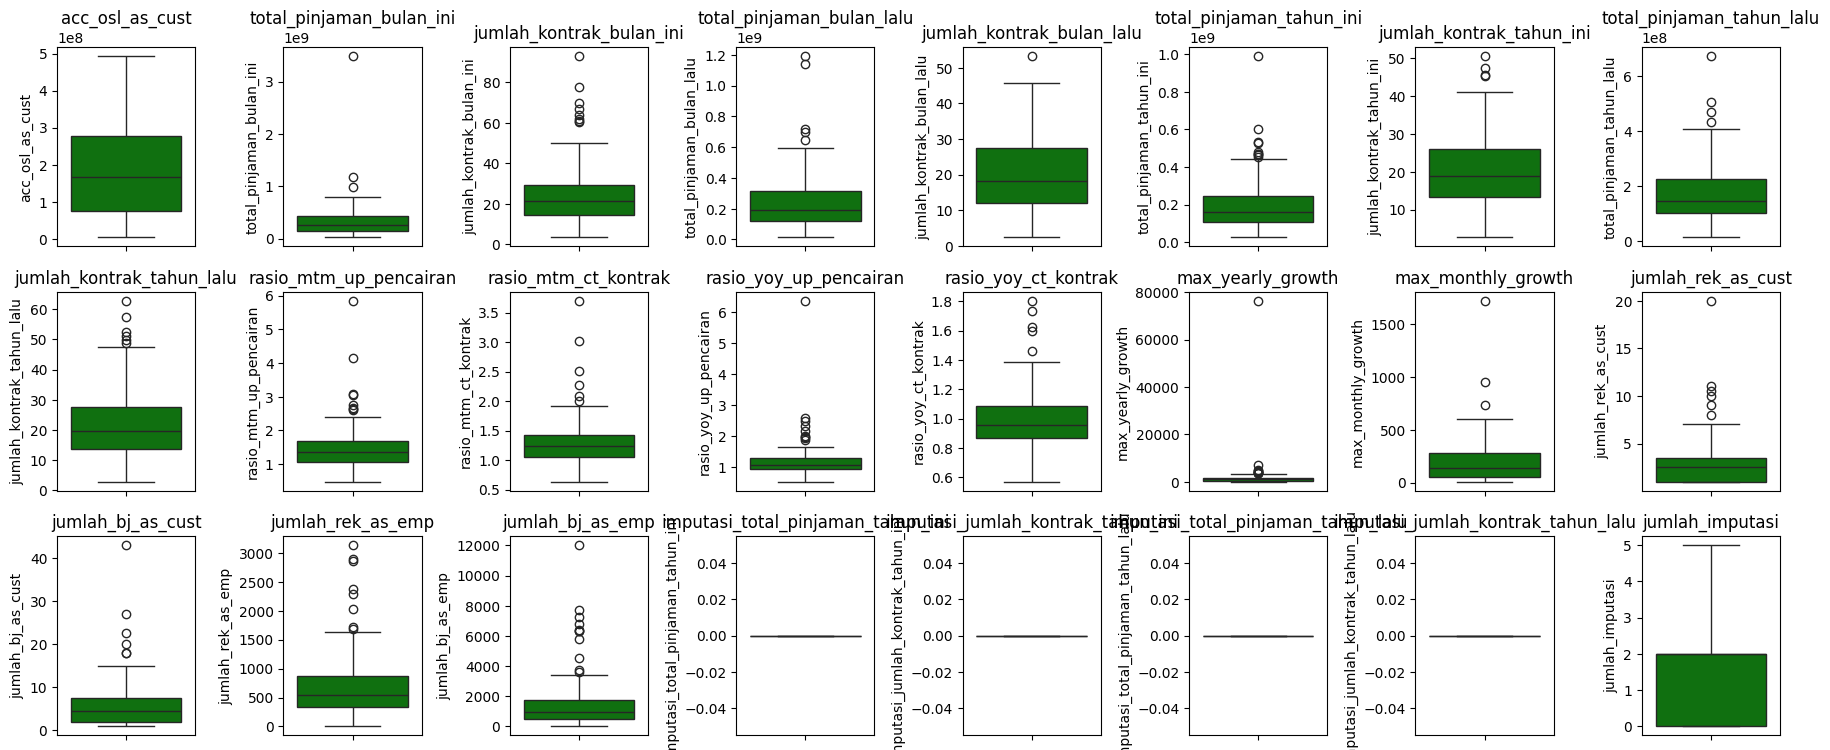

In [81]:
boxplot(df_custom)

In [82]:
def histogram(data):
  plt.figure(figsize=(18, 10))
  for i in range(0, len(numerik)):
      plt.subplot(4, 8, i+1)
      plt.title(numerik[i])
      sns.distplot(data[numerik[i]], color='green', label=i)
      plt.tight_layout()

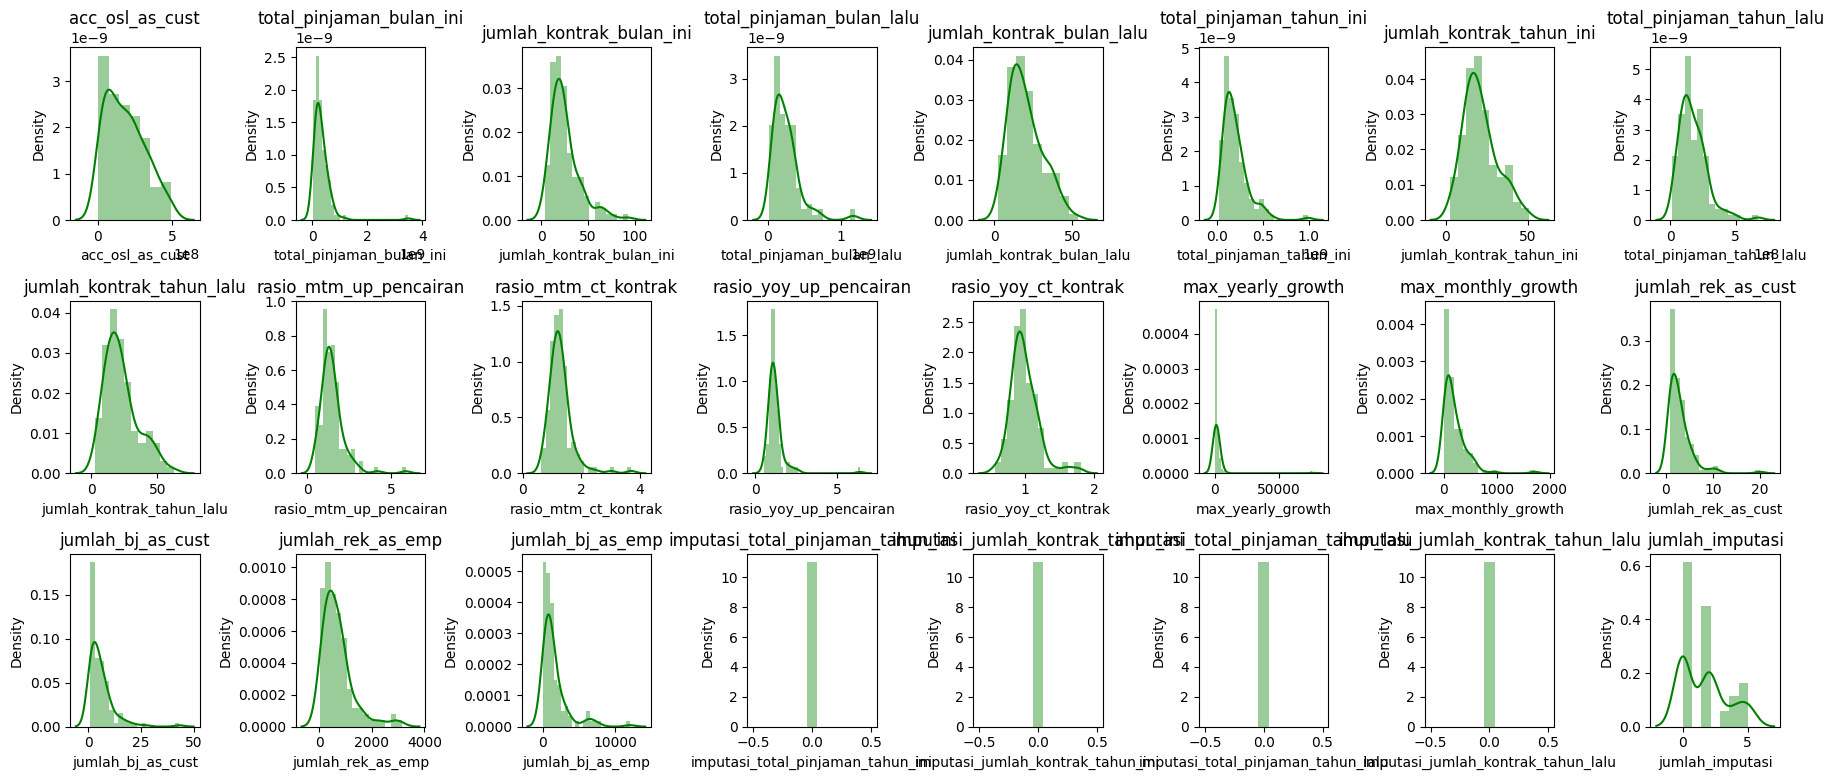

In [83]:
histogram(df_custom)

In [114]:
df_custom.shape[0]

121

In [85]:
# numerik = df_custom.drop(columns=["nik_pendek","branch_code"]).columns.tolist()
# def plot_kde(i):
#     plt.figure(figsize=(18, 10))
#     # plt.title("OSL Karyawan sbg Customer",fontsize=24)
#     plt.xticks(fontsize=24)
#     plt.yticks(fontsize=24)
#     plt.title(numerik[i],fontsize=24)
#     plt.ylabel("Banyak",fontsize=24)
#     # plt.ticklabel_format(style='plain', axis='both')
#     sns.distplot(df_custom[[numerik[i]]], color='green', label=i)
#     plt.tight_layout()

In [86]:
# for i in range(len(numerik)):
#     plot_kde(i)
#     # print("\n")

In [ ]:
# df_custom[[
# 'jumlah_rek_as_cust'
# ,'jumlah_bj_as_cust'
# ,'jumlah_rek_as_emp'
# ,'jumlah_bj_as_emp'
# ]].describe()

In [ ]:
# pd.set_option('display.float_format', '{:.1f}'.format)
# df_custom[["acc_osl_as_cust"]].describe()

In [ ]:
# correlation = df_custom[numerik].corr()
# plt.figure(figsize=(18, 10))
# sns.heatmap(correlation, annot=True, fmt=".1f", cmap='coolwarm')

In [ ]:
# correlation = df_custom[numerik].corr(method="spearman")
# plt.figure(figsize=(18, 10))
# sns.heatmap(correlation, annot=True, fmt=".1f", cmap='coolwarm')

In [117]:
df_selection = df_custom[numerik].drop(columns=[
                                                'total_pinjaman_tahun_lalu',
                                                 
       'rasio_mtm_up_pencairan', 'rasio_mtm_ct_kontrak',
       'rasio_yoy_up_pencairan', 'rasio_yoy_ct_kontrak',
        'jumlah_rek_as_cust', 'jumlah_bj_as_cust'])

In [ ]:
# df_selection.info()

Isolation Forest

full data

In [87]:
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Assuming df_custom[numerik] is your DataFrame with numerical columns
# If not, select only numerical columns
def prepare_and_visualize_tsne_isolation_forest(df_custom, numerical_columns=None):
    """
    Perform t-SNE dimensionality reduction and apply Isolation Forest for anomaly detection
    
    Parameters:
    df_custom: DataFrame containing your data
    numerical_columns: List of numerical column names (if None, uses all numerical columns)
    """
    
    # If numerical_columns not specified, select all numerical columns
    if numerical_columns is None:
        numerical_columns = df_custom.select_dtypes(include=[np.number]).columns.tolist()
    
    # Extract numerical data
    X = df_custom[numerical_columns].copy()
    
    # Handle missing values if any
    X = X.fillna(X.mean())
    
    # Standardize the features
    print("Standardizing features...")
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Apply t-SNE for dimensionality reduction (3D to 2D)
    print("Applying t-SNE dimensionality reduction...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
    X_tsne = tsne.fit_transform(X_scaled)
    
    # Create DataFrame with t-SNE results
    df_tsne = pd.DataFrame(X_tsne, columns=['TSNE1', 'TSNE2'])
    
    # Apply Isolation Forest on the original scaled data
    print("Applying Isolation Forest for anomaly detection...")
    isolation_forest = IsolationForest(
        contamination=0.01,  # Expected proportion of outliers
        random_state=42,
        n_estimators=50
    )
    
    # Fit and predict anomalies
    y_pred = isolation_forest.fit_predict(X_scaled)
    
    # Convert predictions to labels (1: normal, -1: anomaly)
    df_tsne['anomaly'] = y_pred
    df_tsne['anomaly_label'] = df_tsne['anomaly'].map({1: 'Normal', -1: 'Anomaly'})
    
    # Add anomaly scores
    df_tsne['anomaly_score'] = isolation_forest.score_samples(X_scaled)
    
    # Add back original index if available
    if df_custom.index.name is not None:
        df_tsne.index = df_custom.index
    
    # Visualization 1: 2D t-SNE scatter plot with anomaly detection
    print("\nCreating visualizations...")
    
    fig1 = px.scatter(
        df_tsne, 
        x='TSNE1', 
        y='TSNE2',
        color='anomaly_label',
        color_discrete_map={'Normal': 'blue', 'Anomaly': 'red'},
        title='t-SNE Visualization with Isolation Forest Anomaly Detection',
        labels={'TSNE1': 't-SNE Component 1', 'TSNE2': 't-SNE Component 2'},
        hover_data={'anomaly_score': ':.4f'}
    )
    
    fig1.update_traces(marker=dict(size=8, opacity=0.7))
    fig1.show()
    
    # Visualization 2: 3D scatter plot of original data (first 3 features) with anomaly coloring
    if len(numerical_columns) >= 3:
        # Use first 3 numerical features for 3D visualization
        feature_names = numerical_columns[:3]
        
        fig2 = px.scatter_3d(
            df_custom, 
            x=feature_names[0], 
            y=feature_names[1], 
            z=feature_names[2],
            color=df_tsne['anomaly_label'],
            color_discrete_map={'Normal': 'blue', 'Anomaly': 'red'},
            title=f'3D Original Data with Anomaly Detection (first 3 features)',
            opacity=0.7
        )
        
        fig2.show()
    
    # Visualization 3: Distribution of anomaly scores
    fig3 = px.histogram(
        df_tsne, 
        x='anomaly_score',
        color='anomaly_label',
        nbins=50,
        title='Distribution of Anomaly Scores',
        labels={'anomaly_score': 'Anomaly Score', 'count': 'Frequency'},
        color_discrete_map={'Normal': 'blue', 'Anomaly': 'red'}
    )
    
    fig3.show()
    
    # Summary statistics
    print("\n" + "="*50)
    print("ANOMALY DETECTION SUMMARY")
    print("="*50)
    anomaly_counts = df_tsne['anomaly_label'].value_counts()
    print(f"Normal samples: {anomaly_counts.get('Normal', 0)}")
    print(f"Anomaly samples: {anomaly_counts.get('Anomaly', 0)}")
    print(f"Anomaly percentage: {(anomaly_counts.get('Anomaly', 0)/len(df_tsne)*100):.2f}%")
    
    # t-SNE performance metrics
    print(f"\nt-SNE KL-divergence: {tsne.kl_divergence_:.4f}")
    print(f"Isolation Forest threshold: {isolation_forest.offset_:.4f}")
    
    return df_tsne, isolation_forest, tsne

# Alternative: Separate function for just training and prediction
def train_isolation_forest_on_tsne(df_custom, numerical_columns=None, contamination=0.01):
    """
    Train Isolation Forest on t-SNE reduced data
    """
    if numerical_columns is None:
        numerical_columns = df_custom.select_dtypes(include=[np.number]).columns.tolist()
    
    X = df_custom[numerical_columns].fillna(df_custom[numerical_columns].mean())
    
    # Standardize
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Apply t-SNE
    tsne = TSNE(n_components=2, random_state=42)
    X_tsne = tsne.fit_transform(X_scaled)
    
    # Train Isolation Forest on t-SNE results
    iso_forest = IsolationForest(contamination=contamination, random_state=42)
    predictions = iso_forest.fit_predict(X_tsne)
    
    return X_tsne, predictions, iso_forest, tsne


# Usage example:
"""
# Assuming your data is in df_custom with a column called 'numerik' that contains your DataFrame
# Or if df_custom is already your DataFrame:

# Method 1: Complete analysis with visualizations
results_df, iso_forest_model, tsne_model = prepare_and_visualize_tsne_isolation_forest(df_custom)

# Method 2: Just get the reduced data and predictions
X_tsne, predictions, iso_model, tsne_model = train_isolation_forest_on_tsne(df_custom)

# Access the results
anomalies = results_df[results_df['anomaly_label'] == 'Anomaly']
normals = results_df[results_df['anomaly_label'] == 'Normal']

print(f"Detected {len(anomalies)} anomalies")
print(f"Detected {len(normals)} normal samples")
"""

'\n# Assuming your data is in df_custom with a column called \'numerik\' that contains your DataFrame\n# Or if df_custom is already your DataFrame:\n\n# Method 1: Complete analysis with visualizations\nresults_df, iso_forest_model, tsne_model = prepare_and_visualize_tsne_isolation_forest(df_custom)\n\n# Method 2: Just get the reduced data and predictions\nX_tsne, predictions, iso_model, tsne_model = train_isolation_forest_on_tsne(df_custom)\n\n# Access the results\nanomalies = results_df[results_df[\'anomaly_label\'] == \'Anomaly\']\nnormals = results_df[results_df[\'anomaly_label\'] == \'Normal\']\n\nprint(f"Detected {len(anomalies)} anomalies")\nprint(f"Detected {len(normals)} normal samples")\n'

### Pakai seluruh kolom & direduksi t-sne

Standardizing features...
Applying t-SNE dimensionality reduction...
Applying Isolation Forest for anomaly detection...

Creating visualizations...


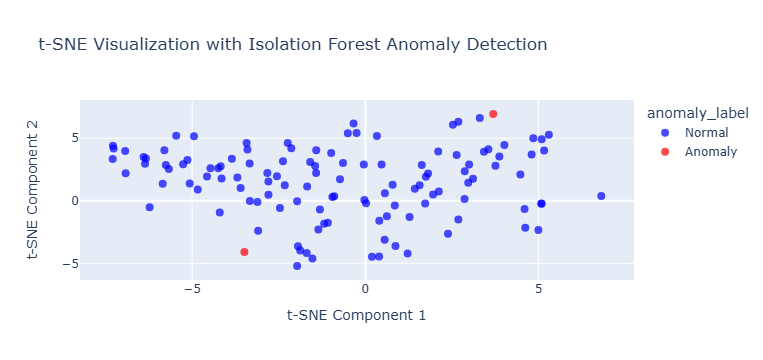

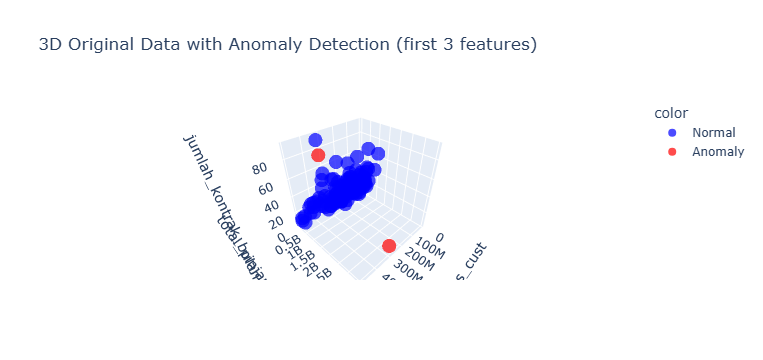

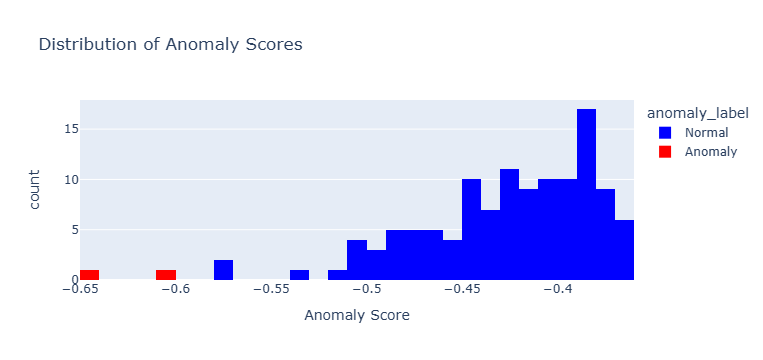


ANOMALY DETECTION SUMMARY
Normal samples: 119
Anomaly samples: 2
Anomaly percentage: 1.65%

t-SNE KL-divergence: 0.5400
Isolation Forest threshold: -0.5972


In [118]:
df_result_tsne_all, iso_forest_model_tsne_all, tsne_model_tsne_all = prepare_and_visualize_tsne_isolation_forest(df_custom)

In [119]:
df_result_tsne_all.rename(columns={'anomaly': 'tsne_all_anomaly', 'anomaly_label': 'tsne_all_anomaly_label', 'anomaly_score': 'tsne_all_anomaly_score'}, inplace=True)

### Pakai kolom tinggi korelasi & direduksi t-sne

Standardizing features...
Applying t-SNE dimensionality reduction...
Applying Isolation Forest for anomaly detection...

Creating visualizations...


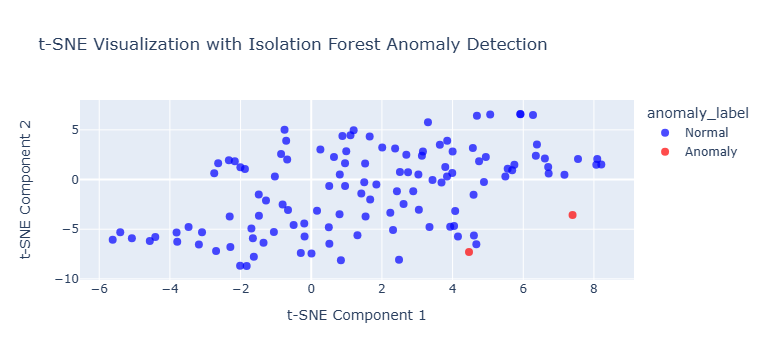

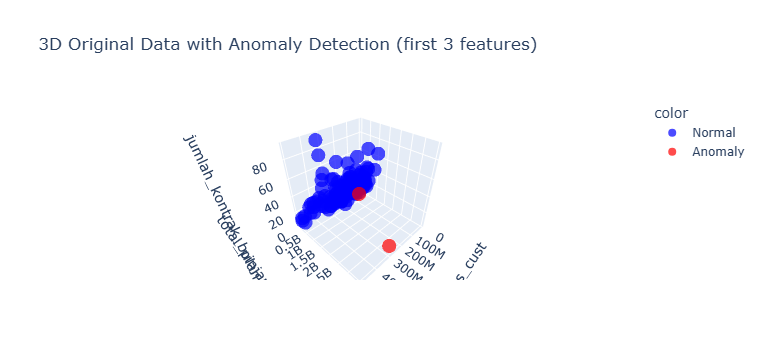

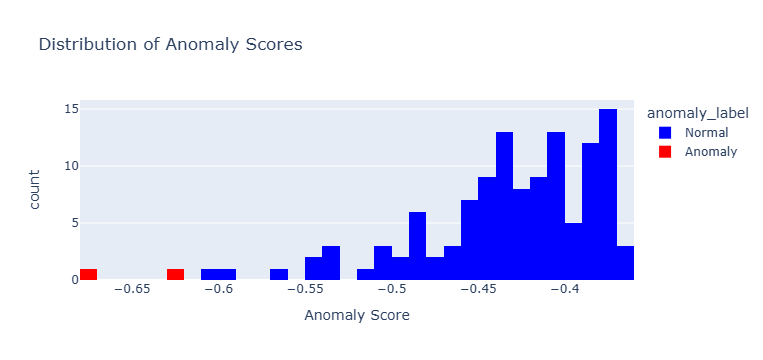


ANOMALY DETECTION SUMMARY
Normal samples: 119
Anomaly samples: 2
Anomaly percentage: 1.65%

t-SNE KL-divergence: 0.3560
Isolation Forest threshold: -0.6169


In [120]:
df_result_tsne_selection, iso_forest_model_tsne_selection, tsne_model_tsne_selection = prepare_and_visualize_tsne_isolation_forest(df_selection)

In [121]:
df_result_tsne_selection.rename(columns={'anomaly': 'tsne_selection_anomaly', 'anomaly_label': 'tsne_selection_anomaly_label', 'anomaly_score': 'tsne_selection_anomaly_score'}, inplace=True)

In [122]:

def prepare_and_visualize_tsne(df_custom, numerical_columns=None, target_column=None):
    """
    Perform t-SNE dimensionality reduction for visualization only
    
    Parameters:
    df_custom: DataFrame containing your data
    numerical_columns: List of numerical column names (if None, uses all numerical columns)
    target_column: Optional column name for coloring (categorical or numerical)
    """
    
    # If numerical_columns not specified, select all numerical columns (excluding target)
    if numerical_columns is None:
        numerical_columns = df_custom.select_dtypes(include=[np.number]).columns.tolist()
        if target_column and target_column in numerical_columns:
            numerical_columns.remove(target_column)
    
    print(f"Using {len(numerical_columns)} numerical features for t-SNE")
    print(f"Features: {numerical_columns[:5]}{'...' if len(numerical_columns) > 5 else ''}")
    
    # Extract numerical data
    X = df_custom[numerical_columns].copy()
    
    # Handle missing values if any
    missing_count = X.isnull().sum().sum()
    if missing_count > 0:
        print(f"Handling {missing_count} missing values using mean imputation...")
        X = X.fillna(X.mean())
    
    # Standardize the features (important for t-SNE)
    print("Standardizing features...")
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Apply t-SNE for dimensionality reduction
    print("Applying t-SNE dimensionality reduction...")
    print("This may take a moment for large datasets...")
    
    # Adjust perplexity based on sample size
    n_samples = X_scaled.shape[0]
    perplexity = min(30, max(5, n_samples // 10))
    
    tsne = TSNE(
        n_components=2, 
        random_state=42, 
        perplexity=perplexity, 
        n_iter=1000,
        init='pca',  # More stable initialization
        learning_rate='auto'
    )
    
    X_tsne = tsne.fit_transform(X_scaled)
    
    # Create DataFrame with t-SNE results
    df_tsne = pd.DataFrame(X_tsne, columns=['TSNE1', 'TSNE2'])
    
    # Add original index if available
    if df_custom.index.name is not None:
        df_tsne.index = df_custom.index
    
    # Add target column for coloring if specified
    if target_column and target_column in df_custom.columns:
        df_tsne[target_column] = df_custom[target_column].values
        
        # Determine if target is categorical or numerical
        if df_custom[target_column].dtype in ['object', 'category'] or df_custom[target_column].nunique() < 10:
            color_type = 'categorical'
            print(f"Using '{target_column}' as categorical color variable")
        else:
            color_type = 'numerical'
            print(f"Using '{target_column}' as numerical color variable")
    else:
        color_type = None
    
    # Add some sample metadata for hover information
    if len(df_custom) <= 1000:  # Only for smaller datasets
        df_tsne['index'] = df_custom.index
        hover_data = ['index']
    else:
        hover_data = None
    
    # Create visualizations
    print("\n" + "="*50)
    print("CREATING VISUALIZATIONS")
    print("="*50)
    
    # Visualization 1: Main t-SNE scatter plot
    if target_column and color_type == 'categorical':
        # Categorical coloring
        fig1 = px.scatter(
            df_tsne, 
            x='TSNE1', 
            y='TSNE2',
            color=target_column,
            title=f't-SNE Visualization (colored by {target_column})',
            labels={'TSNE1': 't-SNE Component 1', 'TSNE2': 't-SNE Component 2'},
            hover_data=hover_data,
            opacity=0.7
        )
    elif target_column and color_type == 'numerical':
        # Numerical coloring with colorbar
        fig1 = px.scatter(
            df_tsne, 
            x='TSNE1', 
            y='TSNE2',
            color=target_column,
            title=f't-SNE Visualization (colored by {target_column})',
            labels={'TSNE1': 't-SNE Component 1', 'TSNE2': 't-SNE Component 2'},
            hover_data=hover_data,
            opacity=0.7,
            color_continuous_scale='viridis'
        )
    else:
        # No coloring
        fig1 = px.scatter(
            df_tsne, 
            x='TSNE1', 
            y='TSNE2',
            title='t-SNE Visualization',
            labels={'TSNE1': 't-SNE Component 1', 'TSNE2': 't-SNE Component 2'},
            hover_data=hover_data,
            opacity=0.7
        )
    
    fig1.update_traces(marker=dict(size=6))
    fig1.update_layout(
        width=900,
        height=600,
        hovermode='closest'
    )
    fig1.show()
    
    # Visualization 2: t-SNE with density contours
    fig2 = px.density_contour(
        df_tsne, 
        x='TSNE1', 
        y='TSNE2',
        title='t-SNE Density Contour Plot',
        labels={'TSNE1': 't-SNE Component 1', 'TSNE2': 't-SNE Component 2'}
    )
    
    fig2.update_traces(contours_coloring="fill", contours_showlabels=True)
    fig2.update_layout(width=900, height=600)
    fig2.show()
    
    # Visualization 3: If we have 3D data, show parallel coordinates
    if len(numerical_columns) >= 3 and len(df_custom) <= 500:  # Limit for readability
        # Select top 10 most important features (if many)
        if len(numerical_columns) > 10:
            feat_sample = numerical_columns[:10]
        else:
            feat_sample = numerical_columns
            
        df_sample = df_custom[feat_sample].copy()
        if target_column and target_column in df_custom.columns:
            df_sample[target_column] = df_custom[target_column]
            
            fig3 = px.parallel_coordinates(
                df_sample,
                color=target_column,
                title=f'Parallel Coordinates Plot (First {len(feat_sample)} Features)',
                color_continuous_scale=px.colors.diverging.Tealrose
            )
        else:
            fig3 = px.parallel_coordinates(
                df_sample,
                title=f'Parallel Coordinates Plot (First {len(feat_sample)} Features)'
            )
        
        fig3.update_layout(width=1000, height=500)
        fig3.show()
    
    # Print summary statistics
    print("\n" + "="*50)
    print("t-SNE VISUALIZATION SUMMARY")
    print("="*50)
    print(f"Number of samples: {n_samples}")
    print(f"Number of features used: {len(numerical_columns)}")
    print(f"t-SNE perplexity: {perplexity}")
    print(f"t-SNE KL-divergence: {tsne.kl_divergence_:.4f} (lower is better)")
    print(f"t-SNE number of iterations: {tsne.n_iter_}")
    
    # Explain KL-divergence
    print("\nInterpretation:")
    print("- Lower KL-divergence indicates better preservation of local structure")
    print("- Points close together in t-SNE space are similar in high-dimensional space")
    print("- Cluster separation suggests natural groupings in your data")
    
    return df_tsne, tsne, scaler

# Simplified function for quick visualization
def quick_tsne_visualization(df_custom, target_col=None):
    """
    Quick t-SNE visualization with minimal parameters
    """
    # Automatically select numerical columns
    num_cols = df_custom.select_dtypes(include=[np.number]).columns.tolist()
    if target_col and target_col in num_cols:
        num_cols.remove(target_col)
    
    # Run t-SNE
    df_tsne, tsne, _ = prepare_and_visualize_tsne(
        df_custom, 
        numerical_columns=num_cols,
        target_column=target_col
    )
    
    return df_tsne

def train_isolation_forest(df_custom, numerical_columns=None, contamination=0.01):
    """
    Train Isolation Forest on t-SNE reduced data
    """
    if numerical_columns is None:
        numerical_columns = df_custom.select_dtypes(include=[np.number]).columns.tolist()
    
    X = df_custom[numerical_columns].fillna(df_custom[numerical_columns].mean())
    
    # Standardize
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    
    
    # Add back original index if available
    if df_custom.index.name is not None:
        df_tsne.index = df_custom.index
    
    # Train Isolation Forest on t-SNE results
    iso_forest = IsolationForest(contamination=contamination, random_state=42)
    predictions = iso_forest.fit_predict(X_scaled)
    
    # Convert predictions to labels (1: normal, -1: anomaly)
    data = {
        "anomaly": predictions,
        "anomaly_score": iso_forest.score_samples(X_scaled)
    }
    
    df_no_tsne = pd.DataFrame(data)
    df_no_tsne["anomaly_label"] = df_no_tsne['anomaly'].map({1: 'Normal', -1: 'Anomaly'})
    
    return X_scaled, predictions, iso_forest, df_no_tsne
# Example usage:
"""
# Basic usage (no coloring)
df_tsne, tsne, scaler = prepare_and_visualize_tsne(df_custom)

# With coloring by a target column
df_tsne, tsne, scaler = prepare_and_visualize_tsne(
    df_custom, 
    target_column='target_variable'
)

# With specific numerical columns
df_tsne, tsne, scaler = prepare_and_visualize_tsne(
    df_custom,
    numerical_columns=['col1', 'col2', 'col3'],
    target_column='category'
)

# Quick visualization
df_tsne = quick_tsne_visualization(df_custom, target_col='target')
"""

"\n# Basic usage (no coloring)\ndf_tsne, tsne, scaler = prepare_and_visualize_tsne(df_custom)\n\n# With coloring by a target column\ndf_tsne, tsne, scaler = prepare_and_visualize_tsne(\n    df_custom, \n    target_column='target_variable'\n)\n\n# With specific numerical columns\ndf_tsne, tsne, scaler = prepare_and_visualize_tsne(\n    df_custom,\n    numerical_columns=['col1', 'col2', 'col3'],\n    target_column='category'\n)\n\n# Quick visualization\ndf_tsne = quick_tsne_visualization(df_custom, target_col='target')\n"

### Pakai seluruh kolom & tanpa direduksi t-sne

Using 20 numerical features for t-SNE
Features: ['acc_osl_as_cust', 'total_pinjaman_bulan_ini', 'jumlah_kontrak_bulan_ini', 'total_pinjaman_bulan_lalu', 'jumlah_kontrak_bulan_lalu']...
Standardizing features...
Applying t-SNE dimensionality reduction...
This may take a moment for large datasets...

CREATING VISUALIZATIONS


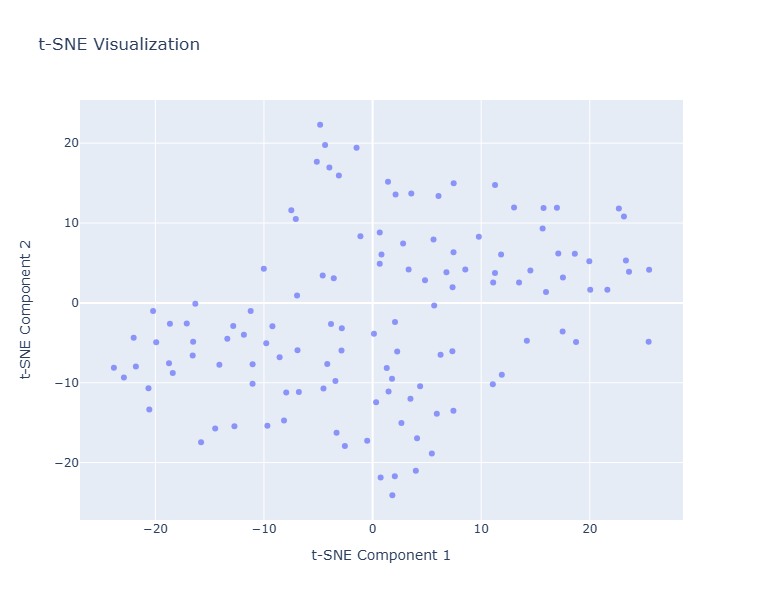

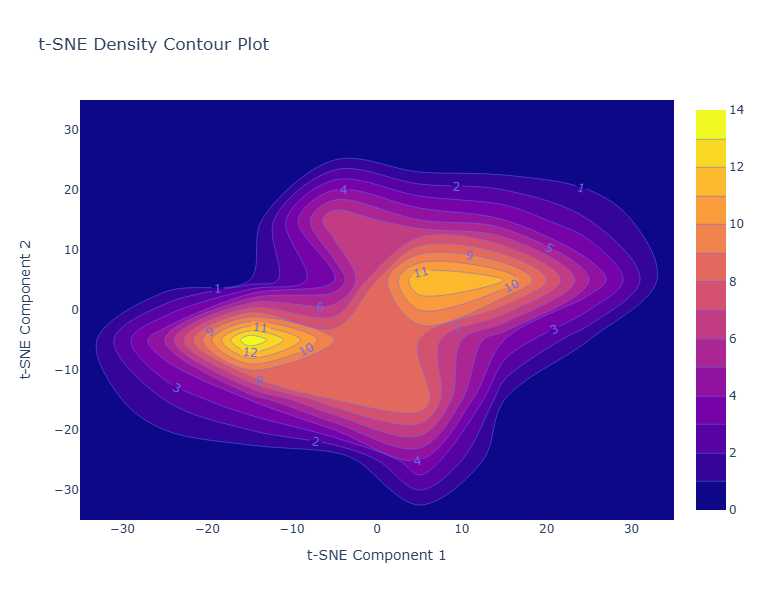

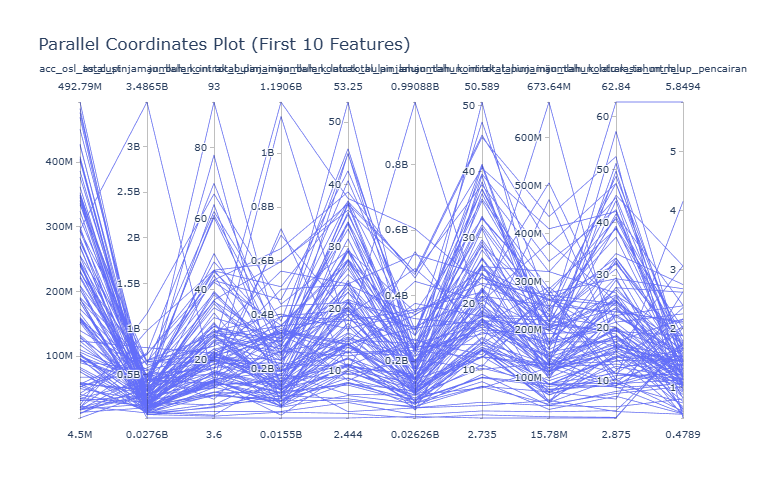


t-SNE VISUALIZATION SUMMARY
Number of samples: 121
Number of features used: 20
t-SNE perplexity: 12
t-SNE KL-divergence: 0.6711 (lower is better)
t-SNE number of iterations: 999

Interpretation:
- Lower KL-divergence indicates better preservation of local structure
- Points close together in t-SNE space are similar in high-dimensional space
- Cluster separation suggests natural groupings in your data


In [123]:
df_result_no_tsne_all, iso_forest_model_no_tsne_all, tsne_model_all = prepare_and_visualize_tsne(df_custom)

In [124]:
X_scaled_no_tsne_all, predictions_no_tsne_all, iso_forest_model_no_tsne_all, df_result_no_tsne_all = train_isolation_forest(df_custom)

In [125]:
df_result_no_tsne_all.rename(columns={'anomaly': 'no_tsne_all_anomaly', 'anomaly_label': 'no_tsne_all_anomaly_label', 'anomaly_score': 'no_tsne_all_anomaly_score'}, inplace=True)

### Pakai kolom tinggi korelasi & tanpa direduksi t-sne

Using 13 numerical features for t-SNE
Features: ['acc_osl_as_cust', 'total_pinjaman_bulan_ini', 'jumlah_kontrak_bulan_ini', 'total_pinjaman_bulan_lalu', 'jumlah_kontrak_bulan_lalu']...
Standardizing features...
Applying t-SNE dimensionality reduction...
This may take a moment for large datasets...

CREATING VISUALIZATIONS


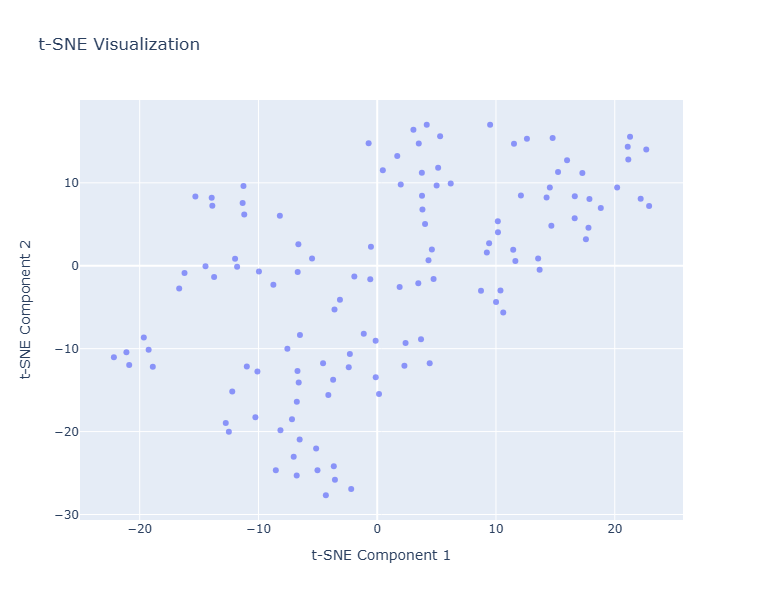

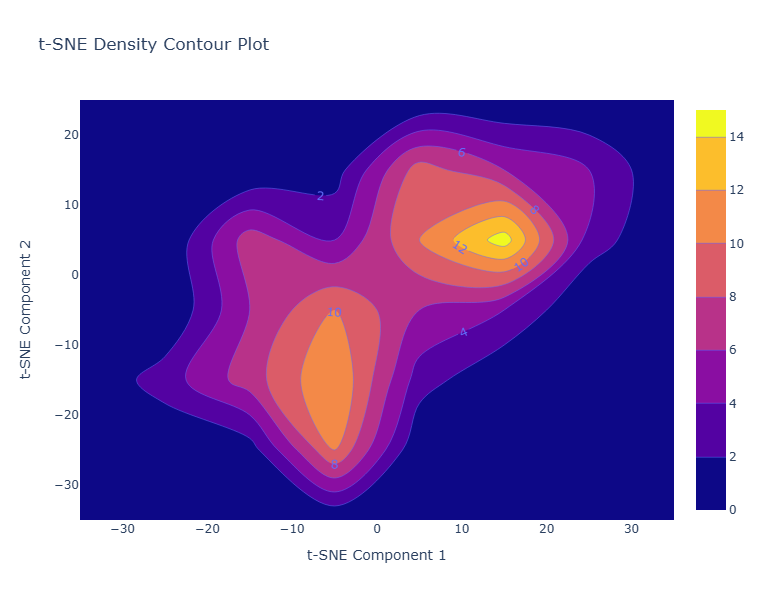

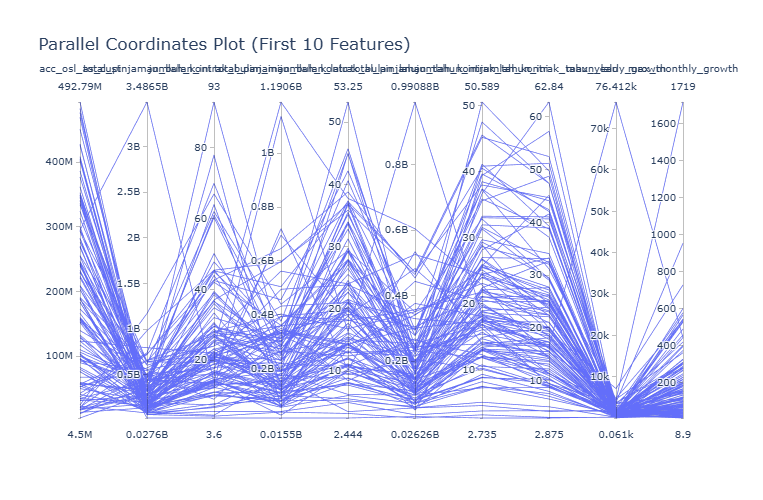


t-SNE VISUALIZATION SUMMARY
Number of samples: 121
Number of features used: 13
t-SNE perplexity: 12
t-SNE KL-divergence: 0.5713 (lower is better)
t-SNE number of iterations: 999

Interpretation:
- Lower KL-divergence indicates better preservation of local structure
- Points close together in t-SNE space are similar in high-dimensional space
- Cluster separation suggests natural groupings in your data


In [126]:
df_result_no_tsne_selection, iso_forest_model_no_tsne_selection, tsne_model_selection = prepare_and_visualize_tsne(df_selection)

In [127]:
X_scaled_no_tsne_selection, predictions_no_tsne_selection, iso_forest_model_no_tsne_selection, df_result_no_tsne_selection = train_isolation_forest(df_selection)

In [128]:
df_result_no_tsne_selection.rename(columns={'anomaly': 'no_tsne_selection_anomaly', 'anomaly_label': 'no_tsne_selection_anomaly_label', 'anomaly_score': 'no_tsne_selection_anomaly_score'}, inplace=True)

### Final data result

In [129]:
df_result_tsne_all["training_strategy"] = "tsne_all"
df_result_tsne_selection["training_strategy"] = "tsne_selection"
df_result_no_tsne_all["training_strategy"] = "no_tsne_all"
df_result_no_tsne_selection["training_strategy"] = "no_tsne_selection"

In [130]:
# df_result_tsne_all 
# df_result_tsne_selection 
# df_result_no_tsne_all 
# df_result_no_tsne_selection 

df_final = pd.concat([df_custom[["nik_pendek","branch_code"]], 
                      df_result_tsne_all,
                      df_result_tsne_selection,
                      df_result_no_tsne_all,
                      df_result_no_tsne_selection], axis=1)

In [ ]:
# numerical_columns = df_custom.select_dtypes(include=[np.number]).columns.tolist()
# X = df_custom[numerical_columns]
# scaler = StandardScaler()
# X_ori = scaler.fit_transform(X)

# iso_forest = IsolationForest(contamination=0.01, random_state=42)
# y_pred = iso_forest.fit_predict(X_ori)

In [ ]:
# len(X_ori)

In [ ]:
# # Convert predictions to labels (1: normal, -1: anomaly)
# df_ori = pd.DataFrame(df_custom, columns=numerik)
# df_ori['anomaly'] = y_pred
# df_ori['anomaly_label'] = df_ori['anomaly'].map({1: 'Normal', -1: 'Anomaly'})

# # Add anomaly scores
# df_ori['anomaly_score'] = iso_forest.score_samples(X_scaled)

In [ ]:
# df_ori[['nik_pendek','branch_code']] = df_num[['nik_pendek','branch_code']] 

In [ ]:
# df_ori["tsne_anomaly"]


In [131]:
df_final

,nik_pendek,branch_code,TSNE1,TSNE2,tsne_all_anomaly,tsne_all_anomaly_label,tsne_all_anomaly_score,training_strategy,TSNE1,TSNE2,...,tsne_selection_anomaly_score,training_strategy,no_tsne_all_anomaly,no_tsne_all_anomaly_score,no_tsne_all_anomaly_label,training_strategy,no_tsne_selection_anomaly,no_tsne_selection_anomaly_score,no_tsne_selection_anomaly_label,training_strategy
0,P86617,60035,-7.264356,4.178569,1,Normal,-0.439665,tsne_all,8.067706,1.478118,...,-0.494620,tsne_selection,1,-0.442414,Normal,no_tsne_all,1,-0.485126,Normal,no_tsne_selection
1,P86706,60723,-3.694488,1.857712,1,Normal,-0.398507,tsne_all,2.739364,0.722869,...,-0.379027,tsne_selection,1,-0.383820,Normal,no_tsne_all,1,-0.386584,Normal,no_tsne_selection
2,P86770,10925,-5.848936,1.360054,1,Normal,-0.400897,tsne_all,3.160854,2.810489,...,-0.373264,tsne_selection,1,-0.389131,Normal,no_tsne_all,1,-0.376042,Normal,no_tsne_selection
3,P87084,11470,4.011368,4.457981,1,Normal,-0.445048,tsne_all,-3.792389,-6.273477,...,-0.455318,tsne_selection,1,-0.449400,Normal,no_tsne_all,1,-0.463466,Normal,no_tsne_selection
4,P87842,14305,-2.828281,2.223110,1,Normal,-0.399894,tsne_all,3.842655,0.314826,...,-0.383658,tsne_selection,1,-0.394730,Normal,no_tsne_all,1,-0.385164,Normal,no_tsne_selection
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116,P95063,60725,2.968808,1.444765,1,Normal,-0.430672,tsne_all,-1.280619,-2.105896,...,-0.427511,tsne_selection,1,-0.423760,Normal,no_tsne_all,1,-0.428450,Normal,no_tsne_selection
117,P95066,10582,-1.679821,1.144851,1,Normal,-0.383954,tsne_all,4.594038,-1.532706,...,-0.384566,tsne_selection,1,-0.388089,Normal,no_tsne_all,1,-0.393634,Normal,no_tsne_selection
118,Q08985,17286,-6.358474,2.955915,1,Normal,-0.401119,tsne_all,6.612367,2.127275,...,-0.430136,tsne_selection,1,-0.399862,Normal,no_tsne_all,1,-0.429459,Normal,no_tsne_selection
119,Q08999,14012,-4.837625,0.897415,1,Normal,-0.410401,tsne_all,4.001111,2.829358,...,-0.414483,tsne_selection,1,-0.405864,Normal,no_tsne_all,1,-0.426378,Normal,no_tsne_selection


In [ ]:
# df_final.columns

In [132]:
df_final = df_final.drop(columns=["TSNE1","TSNE2"])

In [ ]:
# df_final[df_final['no_tsne_all_anomaly_label']=="Anomaly"]

In [ ]:
# df_final[df_final['no_tsne_selection_anomaly_label']=="Anomaly"]

In [ ]:
# df_final[df_final['tsne_all_anomaly_label']=="Anomaly"]

In [ ]:
# df_final[df_final['tsne_selection_anomaly_label']=="Anomaly"]

In [ ]:
# X_tsne, predictions, iso_model = train_isolation_forest_on_tsne(df_selection)

In [133]:
df_final_1 = df_final.drop(columns=["nik_pendek","branch_code"])

In [134]:
df_final.head()

,nik_pendek,branch_code,tsne_all_anomaly,tsne_all_anomaly_label,tsne_all_anomaly_score,training_strategy,tsne_selection_anomaly,tsne_selection_anomaly_label,tsne_selection_anomaly_score,training_strategy,no_tsne_all_anomaly,no_tsne_all_anomaly_score,no_tsne_all_anomaly_label,training_strategy,no_tsne_selection_anomaly,no_tsne_selection_anomaly_score,no_tsne_selection_anomaly_label,training_strategy
0,P86617,60035,1,Normal,-0.439665,tsne_all,1,Normal,-0.494620,tsne_selection,1,-0.442414,Normal,no_tsne_all,1,-0.485126,Normal,no_tsne_selection
1,P86706,60723,1,Normal,-0.398507,tsne_all,1,Normal,-0.379027,tsne_selection,1,-0.383820,Normal,no_tsne_all,1,-0.386584,Normal,no_tsne_selection
2,P86770,10925,1,Normal,-0.400897,tsne_all,1,Normal,-0.373264,tsne_selection,1,-0.389131,Normal,no_tsne_all,1,-0.376042,Normal,no_tsne_selection
3,P87084,11470,1,Normal,-0.445048,tsne_all,1,Normal,-0.455318,tsne_selection,1,-0.449400,Normal,no_tsne_all,1,-0.463466,Normal,no_tsne_selection
4,P87842,14305,1,Normal,-0.399894,tsne_all,1,Normal,-0.383658,tsne_selection,1,-0.394730,Normal,no_tsne_all,1,-0.385164,Normal,no_tsne_selection


In [135]:
df_num.head()

,nik_pendek,branch_code,acc_osl_as_cust,total_pinjaman_bulan_ini,jumlah_kontrak_bulan_ini,total_pinjaman_bulan_lalu,jumlah_kontrak_bulan_lalu,total_pinjaman_tahun_ini,jumlah_kontrak_tahun_ini,total_pinjaman_tahun_lalu,...,max_monthly_growth,jumlah_rek_as_cust,jumlah_bj_as_cust,jumlah_rek_as_emp,jumlah_bj_as_emp,imputasi_total_pinjaman_tahun_ini,imputasi_jumlah_kontrak_tahun_ini,imputasi_total_pinjaman_tahun_lalu,imputasi_jumlah_kontrak_tahun_lalu,jumlah_imputasi
0,P86617,60035,NaN,66927600.0,5.48,3.994333e+07,4.944444,3.596997e+07,3.804124,2.876553e+07,...,155.315789,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,5.0
1,P86706,60723,100630000.0,207010000.0,19.00,2.208685e+08,23.285714,1.450648e+08,17.382671,1.431087e+08,...,57.865248,1.0,1,137.0,244,0.0,0.0,0.0,0.0,0.0
2,P86770,10925,221230000.0,249276400.0,14.32,2.179995e+08,10.666667,1.597151e+08,15.760252,1.457832e+08,...,265.333333,2.0,3,254.0,429,0.0,0.0,0.0,0.0,0.0
3,P87084,11470,153276749.0,423215000.0,45.50,2.569090e+08,29.142857,2.485272e+08,33.064286,2.748967e+08,...,80.166667,6.0,8,1678.0,4534,0.0,0.0,0.0,0.0,0.0
4,P87842,14305,59474500.0,293142400.0,16.68,1.303590e+08,10.952381,1.480665e+08,17.382759,1.690326e+08,...,167.750000,1.0,1,310.0,408,0.0,0.0,0.0,0.0,0.0


In [136]:
df_explain_all = pd.merge(df_final, df_num, on=['nik_pendek','branch_code'], how='left')

In [137]:
df_explain_all.columns

Index(['nik_pendek', 'branch_code', 'tsne_all_anomaly',
       'tsne_all_anomaly_label', 'tsne_all_anomaly_score', 'training_strategy',
       'tsne_selection_anomaly', 'tsne_selection_anomaly_label',
       'tsne_selection_anomaly_score', 'training_strategy',
       'no_tsne_all_anomaly', 'no_tsne_all_anomaly_score',
       'no_tsne_all_anomaly_label', 'training_strategy',
       'no_tsne_selection_anomaly', 'no_tsne_selection_anomaly_score',
       'no_tsne_selection_anomaly_label', 'training_strategy',
       'acc_osl_as_cust', 'total_pinjaman_bulan_ini',
       'jumlah_kontrak_bulan_ini', 'total_pinjaman_bulan_lalu',
       'jumlah_kontrak_bulan_lalu', 'total_pinjaman_tahun_ini',
       'jumlah_kontrak_tahun_ini', 'total_pinjaman_tahun_lalu',
       'jumlah_kontrak_tahun_lalu', 'rasio_mtm_up_pencairan',
       'rasio_mtm_ct_kontrak', 'rasio_yoy_up_pencairan',
       'rasio_yoy_ct_kontrak', 'max_yearly_growth', 'max_monthly_growth',
       'jumlah_rek_as_cust', 'jumlah_bj_as_cust', 

In [138]:
pd.set_option('display.max_columns', None)
logik = (df_explain_all["nik_pendek"]=="P92838") | (df_explain_all["nik_pendek"]=="P94637") | (df_explain_all["nik_pendek"]=="P94704")| (df_explain_all["nik_pendek"]=="P94464")| (df_explain_all["nik_pendek"]=="P94528") |(df_explain_all["nik_pendek"]=="P95031") 
df_explain_all[logik]

,nik_pendek,branch_code,tsne_all_anomaly,tsne_all_anomaly_label,tsne_all_anomaly_score,training_strategy,tsne_selection_anomaly,tsne_selection_anomaly_label,tsne_selection_anomaly_score,training_strategy,no_tsne_all_anomaly,no_tsne_all_anomaly_score,no_tsne_all_anomaly_label,training_strategy,no_tsne_selection_anomaly,no_tsne_selection_anomaly_score,no_tsne_selection_anomaly_label,training_strategy,acc_osl_as_cust,total_pinjaman_bulan_ini,jumlah_kontrak_bulan_ini,total_pinjaman_bulan_lalu,jumlah_kontrak_bulan_lalu,total_pinjaman_tahun_ini,jumlah_kontrak_tahun_ini,total_pinjaman_tahun_lalu,jumlah_kontrak_tahun_lalu,rasio_mtm_up_pencairan,rasio_mtm_ct_kontrak,rasio_yoy_up_pencairan,rasio_yoy_ct_kontrak,max_yearly_growth,max_monthly_growth,jumlah_rek_as_cust,jumlah_bj_as_cust,jumlah_rek_as_emp,jumlah_bj_as_emp,imputasi_total_pinjaman_tahun_ini,imputasi_jumlah_kontrak_tahun_ini,imputasi_total_pinjaman_tahun_lalu,imputasi_jumlah_kontrak_tahun_lalu,jumlah_imputasi
48,P92838,12203,-1,Anomaly,-0.602152,tsne_all,1,Normal,-0.566746,tsne_selection,-1,-0.598757,Anomaly,no_tsne_all,1,-0.572040,Normal,no_tsne_selection,346350000.0,3.153800e+08,78.000000,5.391693e+07,21.066667,1.296872e+08,36.701245,2.158030e+08,62.840000,5.849368,3.702532,0.600952,0.584043,1161.666667,36.347826,3.0,18,2851.0,2993,0.0,0.0,0.0,0.0,0.0
79,P94528,12748,1,Normal,-0.577535,tsne_all,-1,Anomaly,-0.620855,tsne_selection,1,-0.572440,Normal,no_tsne_all,-1,-0.648114,Anomaly,no_tsne_selection,92544106.0,5.473050e+08,12.944444,7.195094e+08,10.166667,5.340796e+08,13.954545,4.704843e+08,16.428571,0.760664,1.273224,1.135170,0.849407,76412.333333,443.800000,NaN,NaN,745.0,12018,0.0,0.0,0.0,0.0,2.0
87,P94637,12284,-1,Anomaly,-0.647868,tsne_all,-1,Anomaly,-0.676636,tsne_selection,-1,-0.627594,Anomaly,no_tsne_all,-1,-0.674928,Anomaly,no_tsne_selection,295000000.0,3.486523e+09,13.727273,1.137290e+09,16.333333,9.908800e+08,18.400722,6.736384e+08,15.419355,3.065642,0.840445,1.470938,1.193352,4835.470588,539.238095,NaN,NaN,443.0,5811,0.0,0.0,0.0,0.0,2.0


In [ ]:
# df_explain_all[~logik]

In [ ]:
# df_explain_all[df_explain_all.drop(columns=['nik_pendek','branch_code']).columns.tolist()].describe()

In [ ]:
# df_explain_all[df_explain_all['jumlah_imputasi']>5.0]

In [ ]:
# df_explain_all[df_explain_all['tsne_all_anomaly_label']=='Anomaly']

In [139]:
df_explain_all['total_anomaly_score'] = (df_explain_all['tsne_all_anomaly_score']+ df_explain_all['no_tsne_all_anomaly_score']+  df_explain_all['tsne_selection_anomaly_score']+  df_explain_all['no_tsne_selection_anomaly_score'])/4

In [140]:
for i in range (df_explain_all.shape[0]):
    df_explain_all.at[i,'total_anomaly_score'] = (df_explain_all.at[i,'total_anomaly_score']-min(df_explain_all['total_anomaly_score']))/(max(df_explain_all['total_anomaly_score'])-min(df_explain_all['total_anomaly_score'])) 

In [ ]:
# df_explain_all['total_anomaly_score'].describe()

In [141]:
df_explain_all['total_anomaly_score']=1.0-df_explain_all['total_anomaly_score'] 

In [142]:
df_explain_all.index

RangeIndex(start=0, stop=121, step=1)

In [143]:
for i in df_explain_all.index:
    if df_explain_all.at[i,'total_anomaly_score']>0.99:
        df_explain_all.at[i,'final_label'] = 'Moderate'
    elif df_explain_all.at[i,'total_anomaly_score']>0.993:
        df_explain_all.at[i,'final_label'] = 'Moderate to High'
    elif df_explain_all.at[i,'total_anomaly_score']>0.996:
        df_explain_all.at[i,'final_label'] = 'High'
    else:
        df_explain_all.at[i,'final_label'] = 'Normal'

In [144]:
df_explain_all['anomaly_count']=0
alomani = ['tsne_all_anomaly_label', 'tsne_selection_anomaly_label', 'no_tsne_all_anomaly_label', 'no_tsne_selection_anomaly_label']


In [145]:
for i in alomani:
    for j in df_explain_all.index:
        if df_explain_all.at[j,i]=='Anomaly':
            df_explain_all.at[j,'anomaly_count'] =  df_explain_all.at[j,'anomaly_count']+1

In [146]:
for i in df_explain_all.index:
    if df_explain_all.at[i,'anomaly_count']==1:
        df_explain_all.at[i,'final_label'] = 'Moderate'
    elif df_explain_all.at[i,'anomaly_count']==2:
        df_explain_all.at[i,'final_label'] = 'Moderate to High'
    elif df_explain_all.at[i,'anomaly_count']>3:
        df_explain_all.at[i,'final_label'] = 'High'

In [ ]:
# df_explain_all

In [ ]:
# df_explain_all[df_explain_all['tsne_all_anomaly_label']=='Anomaly']

In [ ]:
# df_explain_all[df_explain_all['final_label']=='Moderate']

In [ ]:
# df_explain_all['final_label'].unique()

In [147]:
df_explain_all['detection_date'] = today

In [148]:
target_kolom = ['nik_pendek','branch_code','acc_osl_as_cust','total_pinjaman_hari_ini','jumlah_kontrak_hari_ini','total_pinjaman_kemarin','jumlah_kontrak_kemarin','total_pinjaman_minggu_ini','jumlah_kontrak_minggu_ini','total_pinjaman_minggu_lalu','jumlah_kontrak_minggu_lalu','total_pinjaman_bulan_ini','jumlah_kontrak_bulan_ini','total_pinjaman_bulan_lalu','jumlah_kontrak_bulan_lalu','total_pinjaman_tahun_ini','jumlah_kontrak_tahun_ini','total_pinjaman_tahun_lalu','jumlah_kontrak_tahun_lalu','rasio_daily_up_pencairan','rasio_daily_ct_kontrak','rasio_wtw_up_pencairan','rasio_wtw_ct_kontrak','rasio_mtm_up_pencairan','rasio_mtm_ct_kontrak','rasio_yoy_up_pencairan','rasio_yoy_ct_kontrak','max_yearly_growth','max_monthly_growth','jumlah_rek_as_cust','jumlah_bj_as_cust','jumlah_rek_as_emp','jumlah_bj_as_emp','total_anomaly_score','final_label', 'detection_date']

In [162]:
df_explain_all = df_explain_all.drop(columns=['imputasi_total_pinjaman_tahun_ini',
       'imputasi_jumlah_kontrak_tahun_ini',
       'imputasi_total_pinjaman_tahun_lalu',
       'imputasi_jumlah_kontrak_tahun_lalu'])

### Penjelasan model (XAI)

In [149]:
!pip install lime

Lime

In [150]:
df_custom_1 = df_custom.drop(columns=["nik_pendek", "branch_code"])

In [151]:
df_custom_1.values

array([[1.89184432e+08, 6.69276000e+07, 5.48000000e+00, ...,
        3.37000000e+02, 3.81000000e+02, 5.00000000e+00],
       [1.00630000e+08, 2.07010000e+08, 1.90000000e+01, ...,
        1.37000000e+02, 2.44000000e+02, 0.00000000e+00],
       [2.21230000e+08, 2.49276400e+08, 1.43200000e+01, ...,
        2.54000000e+02, 4.29000000e+02, 0.00000000e+00],
       ...,
       [7.63000000e+07, 7.95336364e+07, 6.54545455e+00, ...,
        3.32000000e+02, 4.89000000e+02, 2.00000000e+00],
       [1.57708750e+08, 1.61695833e+08, 1.01666667e+01, ...,
        4.73000000e+02, 7.53000000e+02, 0.00000000e+00],
       [3.12284500e+07, 2.77175600e+08, 2.08400000e+01, ...,
        8.00000000e+02, 2.48200000e+03, 2.00000000e+00]])

In [152]:
import lime
import lime.lime_tabular
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Create a wrapper class for Isolation Forest to work with LIME
class IsolationForestPredictor:
    """
    Wrapper class to make Isolation Forest compatible with LIME
    LIME requires a predict_proba method, which doesn't exist in Isolation Forest
    """
    def __init__(self, isolation_forest_model, scaler=None):
        self.model = isolation_forest_model
        self.scaler = scaler
        
    def predict(self, X):
        """Return predictions: 1 for normal, 0 for anomaly"""
        predictions = self.model.predict(X)
        # Convert from [-1, 1] to [0, 1] (0 = anomaly, 1 = normal)
        return np.where(predictions == 1, 1, 0)
    
    def predict_proba(self, X):
        """
        Return probability estimates for LIME
        Uses anomaly scores to create probabilities
        """
        # Get anomaly scores (negative = more anomalous)
        scores = self.model.score_samples(X)
        
        # Normalize scores to probability range [0, 1]
        # Higher scores (less anomalous) -> higher probability of being normal
        min_score = scores.min()
        max_score = scores.max()
        
        if max_score == min_score:
            normalized_scores = np.ones_like(scores) * 0.5
        else:
            normalized_scores = (scores - min_score) / (max_score - min_score)
        
        # Create probabilities [P(anomaly), P(normal)]
        proba = np.column_stack([1 - normalized_scores, normalized_scores])
        return proba

# Initialize LIME explainers for all 4 models
print("Initializing LIME Explainers for all 4 Isolation Forest Models...")
print("="*70)

# 1. LIME for NO t-SNE ALL columns model
explainer_no_tsne_all = lime.lime_tabular.LimeTabularExplainer(
    training_data=df_custom_1.values,
    feature_names=df_custom_1.columns.tolist(),
    class_names=['Anomaly', 'Normal'],
    mode='classification',
    random_state=42,
    verbose=False
)
predictor_no_tsne_all = IsolationForestPredictor(iso_forest_model_no_tsne_all)

print("✓ LIME Explainer created for: NO t-SNE (All Columns)")

# 2. LIME for NO t-SNE SELECTION model
explainer_no_tsne_selection = lime.lime_tabular.LimeTabularExplainer(
    training_data=df_selection.values,
    feature_names=df_selection.columns.tolist(),
    class_names=['Anomaly', 'Normal'],
    mode='classification',
    random_state=42,
    verbose=False
)
predictor_no_tsne_selection = IsolationForestPredictor(iso_forest_model_no_tsne_selection)

print("✓ LIME Explainer created for: NO t-SNE (Selection)")

# 3. LIME for t-SNE ALL columns model
explainer_tsne_all = lime.lime_tabular.LimeTabularExplainer(
    training_data=df_custom_1.values,
    feature_names=df_custom_1.columns.tolist(),
    class_names=['Anomaly', 'Normal'],
    mode='classification',
    random_state=42,
    verbose=False
)
predictor_tsne_all = IsolationForestPredictor(iso_forest_model_tsne_all)

print("✓ LIME Explainer created for: t-SNE (All Columns)")

# 4. LIME for t-SNE SELECTION model
explainer_tsne_selection = lime.lime_tabular.LimeTabularExplainer(
    training_data=df_selection.values,
    feature_names=df_selection.columns.tolist(),
    class_names=['Anomaly', 'Normal'],
    mode='classification',
    random_state=42,
    verbose=False
)
predictor_tsne_selection = IsolationForestPredictor(iso_forest_model_tsne_selection)

print("✓ LIME Explainer created for: t-SNE (Selection)")
print("="*70)

Initializing LIME Explainers for all 4 Isolation Forest Models...
✓ LIME Explainer created for: NO t-SNE (All Columns)
✓ LIME Explainer created for: NO t-SNE (Selection)
✓ LIME Explainer created for: t-SNE (All Columns)
✓ LIME Explainer created for: t-SNE (Selection)


In [153]:
def explain_anomalies_lime(predictor, explainer, X, y_pred, model_name, top_anomalies=5):
    """
    Generate LIME explanations for detected anomalies
    
    Parameters:
    predictor: IsolationForestPredictor wrapper
    explainer: LIME explainer object
    X: Feature matrix (numpy array)
    y_pred: Predictions from the model
    model_name: Name of the model for display
    top_anomalies: Number of top anomalies to explain
    """
    
    # Find anomaly indices
    anomaly_indices = np.where(y_pred == -1)[0]
    
    if len(anomaly_indices) == 0:
        print(f"No anomalies detected in {model_name}")
        return None
    
    print(f"\n{'='*70}")
    print(f"LIME Explanations for {model_name}")
    print(f"{'='*70}")
    print(f"Total anomalies detected: {len(anomaly_indices)}")
    print(f"Explaining top {min(top_anomalies, len(anomaly_indices))} anomalies...\n")
    
    explanations = []
    
    # Explain top anomalies
    for i, idx in enumerate(anomaly_indices[:top_anomalies]):
        instance = X[idx]
        pred_proba = predictor.predict_proba(instance.reshape(1, -1))
        
        # Generate explanation
        exp = explainer.explain_instance(
            instance,
            predictor.predict_proba,
            num_features=10,  # Top 10 features
            labels=(0,)
        )
        
        explanations.append({
            'index': idx,
            'prediction_prob_anomaly': pred_proba[0, 0],
            'prediction_prob_normal': pred_proba[0, 1],
            'explanation': exp
        })
        
        print(f"Anomaly #{i+1} (Instance Index: {idx})")
        print(f"  Probability - Anomaly: {pred_proba[0, 0]:.4f}, Normal: {pred_proba[0, 1]:.4f}")
        print(f"  Top Contributing Features:")
        
        
        # Extract feature contributions
        for feature, contribution in exp.as_list(label=0):
            print(f"    {feature}: {contribution:+.4f}")
            
        print()
    
    return explanations

# Explain anomalies for NO t-SNE ALL model
print("\n" + "="*70)
print("EXPLAINING ANOMALIES - NO t-SNE (ALL COLUMNS)")
print("="*70)

explanations_no_tsne_all = explain_anomalies_lime(
    predictor_no_tsne_all, 
    explainer_no_tsne_all, 
    df_custom_1.values, 
    predictions_no_tsne_all,
    "NO t-SNE (All Columns)",
    top_anomalies=5
)


EXPLAINING ANOMALIES - NO t-SNE (ALL COLUMNS)

LIME Explanations for NO t-SNE (All Columns)
Total anomalies detected: 2
Explaining top 2 anomalies...

Anomaly #1 (Instance Index: 48)
  Probability - Anomaly: 0.5000, Normal: 0.5000
  Top Contributing Features:
    jumlah_bj_as_cust > 7.50: +0.0928
    jumlah_imputasi <= 0.00: -0.0721
    2.50 < jumlah_rek_as_cust <= 3.50: +0.0557
    rasio_mtm_ct_kontrak > 1.42: +0.0489
    rasio_yoy_up_pencairan <= 0.96: -0.0126
    rasio_yoy_ct_kontrak <= 0.86: +0.0103
    max_monthly_growth <= 53.25: +0.0099
    jumlah_kontrak_tahun_ini > 25.99: +0.0067
    jumlah_bj_as_emp > 1748.00: +0.0061
    jumlah_kontrak_tahun_lalu > 27.71: -0.0051

Anomaly #2 (Instance Index: 87)
  Probability - Anomaly: 0.5000, Normal: 0.5000
  Top Contributing Features:
    1.00 < jumlah_rek_as_cust <= 2.50: -0.1032
    0.00 < jumlah_imputasi <= 2.00: +0.0482
    rasio_yoy_up_pencairan > 1.29: +0.0466
    rasio_mtm_ct_kontrak <= 1.05: -0.0314
    rasio_yoy_ct_kontrak > 1.0

In [154]:
# Explain anomalies for NO t-SNE SELECTION model
print("\n" + "="*70)
print("EXPLAINING ANOMALIES - NO t-SNE (SELECTION)")
print("="*70)

explanations_no_tsne_selection = explain_anomalies_lime(
    predictor_no_tsne_selection, 
    explainer_no_tsne_selection, 
    df_selection.values, 
    predictions_no_tsne_selection,
    "NO t-SNE (Selection)",
    top_anomalies=5
)


EXPLAINING ANOMALIES - NO t-SNE (SELECTION)

LIME Explanations for NO t-SNE (Selection)
Total anomalies detected: 2
Explaining top 2 anomalies...

Anomaly #1 (Instance Index: 79)
  Probability - Anomaly: 0.5000, Normal: 0.5000
  Top Contributing Features:
    0.00 < jumlah_imputasi <= 2.00: +0.2670
    jumlah_kontrak_bulan_lalu <= 12.10: -0.0121
    total_pinjaman_tahun_ini > 243254133.86: -0.0072
    75943750.00 < acc_osl_as_cust <= 166191406.00: -0.0068
    total_pinjaman_bulan_lalu > 313105000.00: +0.0063
    total_pinjaman_bulan_ini > 424260000.00: -0.0057
    jumlah_kontrak_bulan_ini <= 14.32: -0.0037
    max_monthly_growth > 282.88: +0.0036
    max_yearly_growth > 1657.00: -0.0025
    13.46 < jumlah_kontrak_tahun_ini <= 18.90: -0.0023

Anomaly #2 (Instance Index: 87)
  Probability - Anomaly: 0.5000, Normal: 0.5000
  Top Contributing Features:
    0.00 < jumlah_imputasi <= 2.00: +0.2524
    jumlah_kontrak_bulan_ini <= 14.32: -0.0069
    332.00 < jumlah_rek_as_emp <= 543.00: -0.00

In [155]:
# Explain anomalies for t-SNE ALL model
print("\n" + "="*70)
print("EXPLAINING ANOMALIES - t-SNE (ALL COLUMNS)")
print("="*70)

# Get predictions for t-SNE all
y_pred_tsne_all = predictor_tsne_all.predict(df_custom_1.values)
predictions_tsne_all_binary = np.where(df_result_tsne_all['tsne_all_anomaly'].values == 1, 1, 0)
predictions_tsne_all_binary = np.where(predictions_tsne_all_binary == 1, -1, 1)  # Convert back to -1/1

explanations_tsne_all = explain_anomalies_lime(
    predictor_tsne_all, 
    explainer_tsne_all, 
    df_custom_1.values, 
    predictions_tsne_all_binary,
    "t-SNE (All Columns)",
    top_anomalies=5
)


EXPLAINING ANOMALIES - t-SNE (ALL COLUMNS)

LIME Explanations for t-SNE (All Columns)
Total anomalies detected: 119
Explaining top 5 anomalies...

Anomaly #1 (Instance Index: 0)
  Probability - Anomaly: 0.5000, Normal: 0.5000
  Top Contributing Features:
    jumlah_bj_as_cust <= 2.00: -0.1538
    jumlah_imputasi > 2.00: +0.0820
    1.00 < jumlah_rek_as_cust <= 2.50: -0.0758
    1.36 < rasio_mtm_up_pencairan <= 1.68: -0.0380
    1.05 < rasio_mtm_ct_kontrak <= 1.23: -0.0226
    total_pinjaman_bulan_ini <= 152006000.00: +0.0100
    total_pinjaman_bulan_lalu <= 120498571.43: -0.0094
    jumlah_kontrak_tahun_ini <= 13.46: -0.0088
    total_pinjaman_tahun_ini <= 108852903.23: +0.0077
    166191406.00 < acc_osl_as_cust <= 276416911.00: +0.0061

Anomaly #2 (Instance Index: 1)
  Probability - Anomaly: 0.5000, Normal: 0.5000
  Top Contributing Features:
    jumlah_bj_as_cust <= 2.00: -0.1671
    jumlah_imputasi <= 0.00: -0.1456
    jumlah_rek_as_cust <= 1.00: -0.1068
    rasio_mtm_up_pencairan 

In [156]:
# Explain anomalies for t-SNE SELECTION model
print("\n" + "="*70)
print("EXPLAINING ANOMALIES - t-SNE (SELECTION)")
print("="*70)

# Get predictions for t-SNE selection
y_pred_tsne_selection = predictor_tsne_selection.predict(df_selection.values)
predictions_tsne_selection_binary = np.where(df_result_tsne_selection['tsne_selection_anomaly'].values == 1, 1, 0)
predictions_tsne_selection_binary = np.where(predictions_tsne_selection_binary == 1, -1, 1)  # Convert back to -1/1

explanations_tsne_selection = explain_anomalies_lime(
    predictor_tsne_selection, 
    explainer_tsne_selection, 
    df_selection.values, 
    predictions_tsne_selection_binary,
    "t-SNE (Selection)",
    top_anomalies=5
)


EXPLAINING ANOMALIES - t-SNE (SELECTION)

LIME Explanations for t-SNE (Selection)
Total anomalies detected: 119
Explaining top 5 anomalies...

Anomaly #1 (Instance Index: 0)
  Probability - Anomaly: 0.5000, Normal: 0.5000
  Top Contributing Features:
    jumlah_imputasi > 2.00: +0.2707
    jumlah_bj_as_emp <= 500.00: -0.0160
    total_pinjaman_bulan_lalu <= 120498571.43: -0.0103
    jumlah_kontrak_bulan_ini <= 14.32: -0.0097
    133.25 < max_monthly_growth <= 282.88: +0.0090
    jumlah_kontrak_tahun_lalu <= 13.80: -0.0083
    332.00 < jumlah_rek_as_emp <= 543.00: -0.0059
    jumlah_kontrak_tahun_ini <= 13.46: -0.0036
    total_pinjaman_tahun_ini <= 108852903.23: +0.0028
    166191406.00 < acc_osl_as_cust <= 276416911.00: +0.0026

Anomaly #2 (Instance Index: 1)
  Probability - Anomaly: 0.5000, Normal: 0.5000
  Top Contributing Features:
    jumlah_imputasi <= 0.00: -0.4401
    jumlah_bj_as_emp <= 500.00: +0.0010
    18.22 < jumlah_kontrak_bulan_lalu <= 27.48: +0.0008
    108852903.23 <


VISUALIZING LIME EXPLANATIONS FOR FIRST ANOMALY IN EACH MODEL


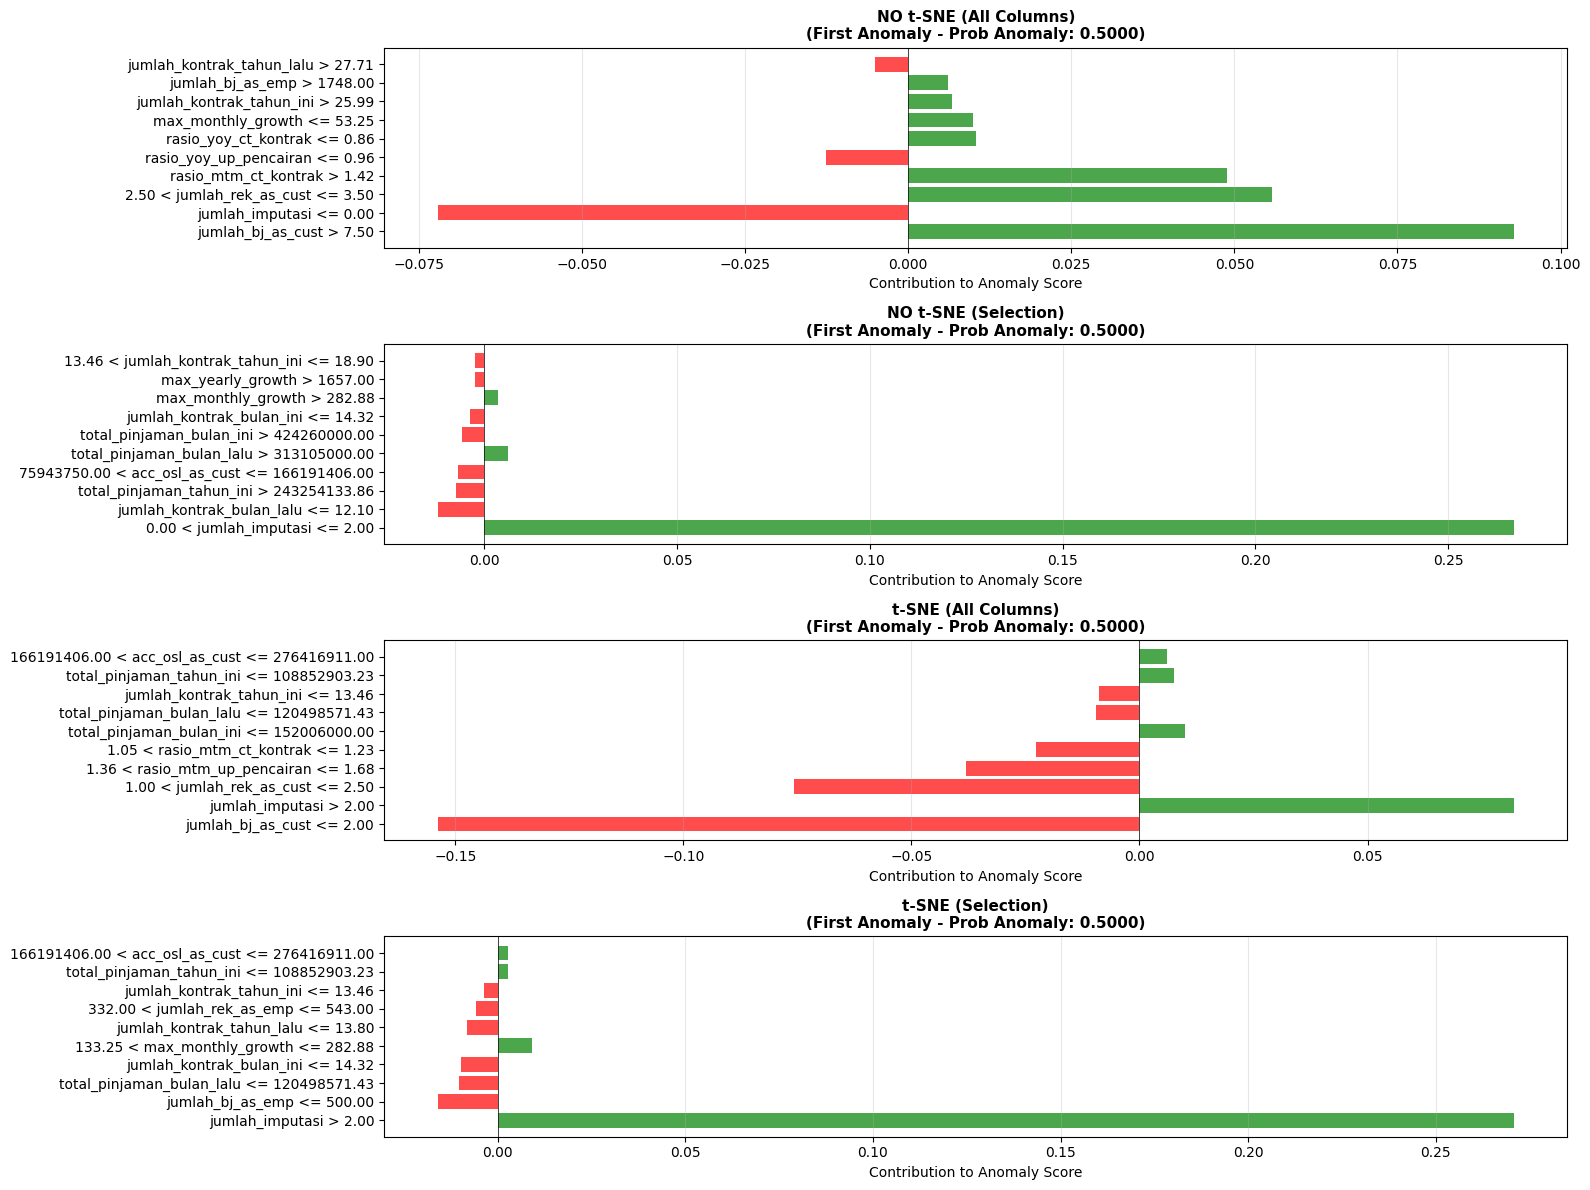

In [157]:
def visualize_lime_explanations_combined(explanations_list, model_names, figsize=(16, 12)):
    """
    Visualize LIME explanations for multiple models side by side
    
    Parameters:
    explanations_list: List of explanation results from explain_anomalies_lime
    model_names: List of model names
    figsize: Figure size for the plot
    """
    import matplotlib.pyplot as plt
    
    num_models = len(explanations_list)
    fig, axes = plt.subplots(num_models, 1, figsize=figsize)
    
    if num_models == 1:
        axes = [axes]
    
    for model_idx, (explanations, model_name) in enumerate(zip(explanations_list, model_names)):
        if explanations is None:
            continue
            
        ax = axes[model_idx]
        
        # Get the first anomaly explanation
        first_exp = explanations[0]
        exp = first_exp['explanation']
        
        # Extract feature contributions
        contributions = exp.as_list(label=0)
        features, values = zip(*contributions)
        
        # Create horizontal bar plot
        y_pos = np.arange(len(features))
        colors = ['red' if v < 0 else 'green' for v in values]
        
        ax.barh(y_pos, values, color=colors, alpha=0.7)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(features)
        ax.set_xlabel('Contribution to Anomaly Score', fontsize=10)
        ax.set_title(f'{model_name}\n(First Anomaly - Prob Anomaly: {first_exp["prediction_prob_anomaly"]:.4f})', 
                    fontsize=11, fontweight='bold')
        ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
        ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Visualize LIME explanations for first anomaly in each model
print("\n" + "="*70)
print("VISUALIZING LIME EXPLANATIONS FOR FIRST ANOMALY IN EACH MODEL")
print("="*70)

explanations_all = [
    explanations_no_tsne_all,
    explanations_no_tsne_selection,
    explanations_tsne_all,
    explanations_tsne_selection
]

model_names_all = [
    "NO t-SNE (All Columns)",
    "NO t-SNE (Selection)",
    "t-SNE (All Columns)",
    "t-SNE (Selection)"
]

# Filter out None values
valid_explanations = [e for e in explanations_all if e is not None]
valid_model_names = [m for e, m in zip(explanations_all, model_names_all) if e is not None]

if valid_explanations:
    visualize_lime_explanations_combined(valid_explanations, valid_model_names)

In [159]:
def extract_feature_importance_from_lime(explanations, feature_names, top_n=10):
    """
    Extract feature importance scores from all LIME explanations
    
    Parameters:
    explanations: List of explanations from explain_anomalies_lime
    feature_names: List of feature names
    top_n: Number of top features to return
    
    Returns:
    DataFrame with feature importance scores
    """
    if explanations is None:
        return None
    
    # Aggregate feature contributions across all anomalies
    feature_scores = {}
    
    for exp_item in explanations:
        exp = exp_item['explanation']
        for feature, contribution in exp.as_list(label=0):
            # Extract feature name (remove ranges like "X <= value")
            feature_clean = feature.split('<=')[0].split('>=')[0].strip()
            
            if feature_clean not in feature_scores:
                feature_scores[feature_clean] = []
            feature_scores[feature_clean].append(abs(contribution))
    
    # Calculate average importance for each feature
    feature_importance = {
        feature: np.mean(scores) 
        for feature, scores in feature_scores.items()
    }
    
    # Sort by importance
    sorted_importance = sorted(feature_importance.items(), key=lambda x: x[1], reverse=True)
    
    # Create DataFrame
    df_importance = pd.DataFrame(sorted_importance[:top_n], columns=['Feature', 'Importance'])
    return df_importance

# Extract and compare feature importance across models
print("\n" + "="*70)
print("FEATURE IMPORTANCE COMPARISON ACROSS MODELS")
print("="*70)

if explanations_no_tsne_all:
    df_imp_no_tsne_all = extract_feature_importance_from_lime(
        explanations_no_tsne_all, 
        df_custom_1.columns.tolist(),
        top_n=10
    )
    print("\nTop 10 Important Features - NO t-SNE (All Columns):")
    print(df_imp_no_tsne_all.to_string(index=False))

if explanations_no_tsne_selection:
    df_imp_no_tsne_selection = extract_feature_importance_from_lime(
        explanations_no_tsne_selection, 
        df_selection.columns.tolist(),
        top_n=10
    )
    print("\nTop 10 Important Features - NO t-SNE (Selection):")
    print(df_imp_no_tsne_selection.to_string(index=False))

if explanations_tsne_all:
    df_imp_tsne_all = extract_feature_importance_from_lime(
        explanations_tsne_all, 
        df_custom_1.columns.tolist(),
        top_n=10
    )
    print("\nTop 10 Important Features - t-SNE (All Columns):")
    print(df_imp_tsne_all.to_string(index=False))

if explanations_tsne_selection:
    df_imp_tsne_selection = extract_feature_importance_from_lime(
        explanations_tsne_selection, 
        df_selection.columns.tolist(),
        top_n=10
    )
    print("\nTop 10 Important Features - t-SNE (Selection):")
    print(df_imp_tsne_selection.to_string(index=False))

print("\n" + "="*70)


FEATURE IMPORTANCE COMPARISON ACROSS MODELS

Top 10 Important Features - NO t-SNE (All Columns):
                      Feature  Importance
    1.00 < jumlah_rek_as_cust    0.103213
     jumlah_bj_as_cust > 7.50    0.092790
              jumlah_imputasi    0.072091
    2.50 < jumlah_rek_as_cust    0.055702
  rasio_mtm_ct_kontrak > 1.42    0.048892
       0.00 < jumlah_imputasi    0.048245
rasio_yoy_up_pencairan > 1.29    0.046556
         rasio_mtm_ct_kontrak    0.031426
       rasio_yoy_up_pencairan    0.012595
         rasio_yoy_ct_kontrak    0.010343

Top 10 Important Features - NO t-SNE (Selection):
                                 Feature  Importance
                  0.00 < jumlah_imputasi    0.259712
               jumlah_kontrak_bulan_lalu    0.012055
           75943750.00 < acc_osl_as_cust    0.006760
 total_pinjaman_tahun_ini > 243254133.86    0.005646
                jumlah_kontrak_bulan_ini    0.005297
total_pinjaman_bulan_lalu > 313105000.00    0.004903
              332.

In [163]:
df_imp_tsne_all["training_strategy"] = "tsne_all"
df_imp_tsne_selection["training_strategy"] = "tsne_selection"
df_imp_no_tsne_all["training_strategy"] = "no_tsne_all"
df_imp_no_tsne_selection["training_strategy"] = "no_tsne_selection"



In [166]:
df_imp_tsne_all["detection_date"]     = today
df_imp_tsne_selection["detection_date"]  =today
df_imp_no_tsne_all["detection_date"] = today
df_imp_no_tsne_selection["detection_date"]=today

In [ ]:
def create_lime_summary_report(df_result_no_tsne_all, df_result_no_tsne_selection, 
                               df_result_tsne_all, df_result_tsne_selection):
    """
    Create a comprehensive summary report of LIME explanations and model performance
    """
    
    print("\n" + "="*70)
    print("COMPREHENSIVE LIME ANALYSIS SUMMARY REPORT")
    print("="*70)
    
    print("\n1. ANOMALY DETECTION SUMMARY")
    print("-" * 70)
    
    results_summary = {
        'Model': [
            'NO t-SNE (All Columns)',
            'NO t-SNE (Selection)',
            't-SNE (All Columns)',
            't-SNE (Selection)'
        ],
        'Anomalies Detected': [
            (df_result_no_tsne_all['no_tsne_all_anomaly_label'] == 'Anomaly').sum(),
            (df_result_no_tsne_selection['no_tsne_selection_anomaly_label'] == 'Anomaly').sum(),
            (df_result_tsne_all['tsne_all_anomaly_label'] == 'Anomaly').sum(),
            (df_result_tsne_selection['tsne_selection_anomaly_label'] == 'Anomaly').sum()
        ],
        'Normal Samples': [
            (df_result_no_tsne_all['no_tsne_all_anomaly_label'] == 'Normal').sum(),
            (df_result_no_tsne_selection['no_tsne_selection_anomaly_label'] == 'Normal').sum(),
            (df_result_tsne_all['tsne_all_anomaly_label'] == 'Normal').sum(),
            (df_result_tsne_selection['tsne_selection_anomaly_label'] == 'Normal').sum()
        ],
        'Anomaly Rate (%)': [
            ((df_result_no_tsne_all['no_tsne_all_anomaly_label'] == 'Anomaly').sum() / len(df_result_no_tsne_all)) * 100,
            ((df_result_no_tsne_selection['no_tsne_selection_anomaly_label'] == 'Anomaly').sum() / len(df_result_no_tsne_selection)) * 100,
            ((df_result_tsne_all['tsne_all_anomaly_label'] == 'Anomaly').sum() / len(df_result_tsne_all)) * 100,
            ((df_result_tsne_selection['tsne_selection_anomaly_label'] == 'Anomaly').sum() / len(df_result_tsne_selection)) * 100
        ]
    }
    
    df_summary = pd.DataFrame(results_summary)
    print(df_summary.to_string(index=False))
    
    print("\n2. LIME EXPLAINABILITY INSIGHTS")
    print("-" * 70)
    print("""
How LIME Explains Isolation Forest:
- LIME creates local surrogate models to explain predictions
- It uses feature importance based on anomaly scores
- Positive contributions indicate features that support "anomaly" classification
- Negative contributions indicate features that support "normal" classification
- Higher absolute values indicate stronger influence on the prediction

Key Insights:
1. Feature Selection Impact:
   - Comparing "All Columns" vs "Selection" shows impact of feature selection
   - Models with fewer features (Selection) may have more interpretable explanations
   
2. t-SNE Dimensionality Reduction:
   - t-SNE reduces data to 2D but may lose feature-level interpretability
   - Direct Isolation Forest provides better feature-level explanations
   
3. Anomaly Scoring:
   - Anomaly score represents how isolated an instance is
   - More negative scores = more anomalous
   - Feature contributions show which attributes cause isolation
    """)
    
    print("\n3. MODEL COMPARISON RECOMMENDATIONS")
    print("-" * 70)
    
    # Determine best model based on criteria
    print("""
Choosing Between Models:

For Production Use:
- NO t-SNE (All Columns): Best for capturing all patterns
  ✓ Uses all available information
  ✓ More comprehensive anomaly detection
  ✗ May include noisy features
  
- NO t-SNE (Selection): Recommended baseline
  ✓ Uses high-correlation features only
  ✓ Better interpretability
  ✓ Faster computation
  ✗ May miss complex multi-feature patterns

For Visualization/Analysis:
- t-SNE (All/Selection): Good for visual exploration
  ✓ 2D visualization helps with clustering
  ✗ Loses feature-level interpretability
  ✗ Slower to compute

Recommendation: Use NO t-SNE (Selection) for production
- Best balance of performance, interpretability, and speed
- LIME explanations are most meaningful with selected features
    """)
    
    print("\n4. HOW TO INTERPRET LIME EXPLANATIONS")
    print("-" * 70)
    print("""
Example Output Interpretation:
"rasio_wtw_up_pencairan <= 0.5" : +0.25
- This means: When rasio_wtw_up_pencairan is <= 0.5
- It contributes +0.25 to the anomaly score
- This feature SUPPORTS anomaly classification

"total_pinjaman_hari_ini >= 1000000" : -0.15
- This means: When total_pinjaman_hari_ini is >= 1000000
- It contributes -0.15 to the anomaly score
- This feature OPPOSES anomaly classification (supports normality)

Taking Action:
1. Review top contributing features for anomalies
2. Verify business logic: Do anomalies make sense?
3. Adjust contamination threshold if needed
4. Monitor detected anomalies in production
    """)
    
    print("\n" + "="*70)

# Generate the summary report
create_lime_summary_report(df_result_no_tsne_all, df_result_no_tsne_selection,
                          df_result_tsne_all, df_result_tsne_selection)

print("\n✓ LIME Analysis Complete!")
print("→ Use the explanations above to understand what makes each anomaly unique")
print("→ Share feature importance results with domain experts for validation")

## Masukin ke BigQuery

In [169]:
df_final_explainer = pd.concat([ 
                      df_imp_tsne_all,
                      df_imp_tsne_selection,
                      df_imp_no_tsne_all,
                      df_imp_no_tsne_selection], axis=0)

In [170]:
df_final_explainer

,Feature,Importance,training_strategy,detection_date
0,jumlah_rek_as_cust > 3.50,0.181608,tsne_all,2026-02-19
1,jumlah_bj_as_cust,0.163706,tsne_all,2026-02-19
2,jumlah_imputasi,0.144346,tsne_all,2026-02-19
3,jumlah_rek_as_cust,0.107350,tsne_all,2026-02-19
4,rasio_mtm_ct_kontrak > 1.42,0.096906,tsne_all,2026-02-19
5,jumlah_bj_as_cust > 7.50,0.094252,tsne_all,2026-02-19
6,jumlah_imputasi > 2.00,0.082015,tsne_all,2026-02-19
7,1.00 < jumlah_rek_as_cust,0.077254,tsne_all,2026-02-19
8,rasio_mtm_up_pencairan,0.072568,tsne_all,2026-02-19
9,rasio_mtm_ct_kontrak,0.050707,tsne_all,2026-02-19


In [174]:
from google.cloud import bigquery
import pandas as pd

# Define your BigQuery project and table details
project_id = "pgd-dev-data-analytics"
table_id = "datamart_audit.dm_dt_sidik_ml_employee_explainer"


# Initialize the client
key_path = '/home/jupyterhub/SA/jupyter-pgd-dev-data-analytics-296ca984dd2f.json'
credentials = service_account.Credentials.from_service_account_file(
    key_path, scopes=["https://www.googleapis.com/auth/cloud-platform"],
)
bq_client = bigquery.Client(credentials=credentials, project=credentials.project_id)

# Configure the job to append data
job_config = bigquery.LoadJobConfig(
    write_disposition="WRITE_APPEND" # Appends to an existing table
    # You can add schema definition or let BigQuery auto-detect (if table doesn't exist)
)

# Load the data
job = bq_client.load_table_from_dataframe(
    df_final_explainer, table_id, job_config=job_config
)

# Wait for the job to complete
job.result() 

print(f"Loaded {len(df_final_explainer)} rows into {table_id}.")


Loaded 121 rows into datamart_audit.dm_dt_sidik_ml_employee_explainer.


In [198]:
def import_sum_symptom(df,dest_table):

    if df.empty:
        print(f"DataFrame is empty. Skipping upload to {dest_table}\n")
        return  # Exit the function early
    
    # 1. Standardize "Object/String" columns
    # This converts real NaNs and 'NaN' strings into a format BQ likes
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = df[col].astype(str).replace(['None', 'nan', 'NaN', 'null', '<NA>'], None)

    # 2. Fix Numeric columns with NaNs
    # Standard 'int64' cannot hold NaNs. You must use 'Int64' (Capital I) 
    # or BigQuery will complain about Float vs Int.
    for col in df.select_dtypes(include=['int64', 'float64']).columns:
        # This keeps the numbers but allows for proper Nulls
        df[col] = df[col].replace({np.nan: None})
    #clean the df
    for col in df.columns:
        df[col] = np.where(df[col] == 'NaN', None, df[col])
    #     # If the column is an 'object' (string-like), make sure EVERYTHING is a string
        if df[col].dtypes == 'object':
            df[col] = df[col].astype(str).replace('nan', None).replace('None', None)
    #     # If you expect it to be numeric, force it and turn errors to NaN
        elif 'int' in str(df[col].dtypes).lower():
             df[col] = pd.to_numeric(df[col], errors='coerce')
                
    # mapping pandas dtype ke BQ type
    dtype_to_bq = {
        'object': 'STRING',
        'int64': 'INT64',
        'Int64': 'INT64',
        'int32' : 'INT64',
        'float64': 'FLOAT64',
        'float32': 'FLOAT64',
        'datetime64[ns]': 'TIMESTAMP',
        'datetime64[us, UTC]':'TIMESTAMP',
        'datetime64[us]':'TIMESTAMP',
        'dbdate':'TIMESTAMP'
    }

    # bangun schema dynamically
    schema = []
    for col, dtype in df.dtypes.items():
        dt = str(dtype)
        bq_type = dtype_to_bq.get(dt)
        if not bq_type:
            raise ValueError(f"Unknown dtype '{dt}' for column '{col}'")
        schema.append(bigquery.SchemaField(col, bq_type))

    # config load job
    job_config = bigquery.LoadJobConfig(
        schema=schema,
        write_disposition="WRITE_APPEND"        
        #write_disposition="WRITE_TRUNCATE" if i == 0 else "WRITE_APPEND"
    )

    # load ke BQ
    job = bq_client.load_table_from_dataframe(df, dest_table, job_config=job_config)
    job.result()
    print(f"loaded {job.output_rows} rows\n to", dest_table) 
    

In [200]:
duplicate_cols = df_explain_all.columns[df_explain_all.columns.duplicated()]
df_explain_all.drop(columns=duplicate_cols, inplace=True)

In [201]:
import_sum_symptom(df_explain_all, "pgd-dev-data-analytics.datamart_audit.dm_dt_sidik_ml_employee")

loaded 121 rows
 to pgd-dev-data-analytics.datamart_audit.dm_dt_sidik_ml_employee
